# NanoOracle — Analyse pour split train/test
Répartition des outputs (Size, PDI, Zeta, EE%) par article source,
pour construire un split qui minimise les outliers dans le jeu de test.

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

INPUT_PATH  = INPUT_PATH = r'C:\Pierre\D4Gen_2026\MVP_public_research\NanoOracle_Dataset_public_research.xlsx'
TEST_RATIO  = 0.20

TARGETS = {
    'Size (Z-avg)':   'Size (nm)',
    'PDI':            'PDI',
    'Zeta Potential': 'Zeta (mV)',
    'EE%':            'EE (%)',
}
SOURCE_COL   = 'Source'
C_MAIN, C_WARN, C_OK = '#2E86AB', '#E84855', '#3BB273'

## 1 — Chargement

In [3]:
df = pd.read_excel(INPUT_PATH, header=1).iloc[1:].reset_index(drop=True)
for col in TARGETS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[SOURCE_COL] = df[SOURCE_COL].astype(str).str.strip()

print(f'{len(df)} formulations — {df[SOURCE_COL].nunique()} articles sources')
df[list(TARGETS) + [SOURCE_COL]].head(3)

224 formulations — 26 articles sources


,Size (Z-avg),PDI,Zeta Potential,EE%,Source
0,87.72,NaN,NaN,77.97,"Ly et al., 2022"
1,82.62,NaN,NaN,76.73,"Ly et al., 2022"
2,85.51,NaN,NaN,87.91,"Ly et al., 2022"


## 2 — Disponibilité des targets par article

In [4]:
rows = []
for src, grp in df.groupby(SOURCE_COL):
    row = {'Source': src, 'N_total': len(grp)}
    for col, label in TARGETS.items():
        present = grp[col].notna().sum()
        row[f'{label}_n']     = present
        row[f'{label}_miss%'] = round(100 * (1 - present / len(grp)), 1)
    rows.append(row)
avail = pd.DataFrame(rows).sort_values('N_total', ascending=False).reset_index(drop=True)
avail

,Source,N_total,Size (nm)_n,Size (nm)_miss%,PDI_n,PDI_miss%,Zeta (mV)_n,Zeta (mV)_miss%,EE (%)_n,EE (%)_miss%
0,"Swingle et al., 2025",106,106,0.0,106,0.0,98,7.5,106,0.0
1,"Roces et al., 2020",33,33,0.0,33,0.0,31,6.1,9,72.7
2,"Billingsley et al., 2023",29,29,0.0,29,0.0,0,100.0,0,100.0
3,"Laramy et al., 2024",9,9,0.0,9,0.0,0,100.0,9,0.0
4,"Kenjo et al,, 2021",8,8,0.0,8,0.0,0,100.0,8,0.0
5,"Ly et al., 2022",6,6,0.0,0,100.0,0,100.0,6,0.0
6,"Forrester et al., 2025",4,4,0.0,4,0.0,0,100.0,4,0.0
7,"Sato et al., 2020",4,4,0.0,0,100.0,0,100.0,0,100.0
8,"Belliveau/Yu et al., 2012",3,3,0.0,3,0.0,3,0.0,3,0.0
9,"Ferraresso et al., 2022",2,2,0.0,2,0.0,2,0.0,2,0.0


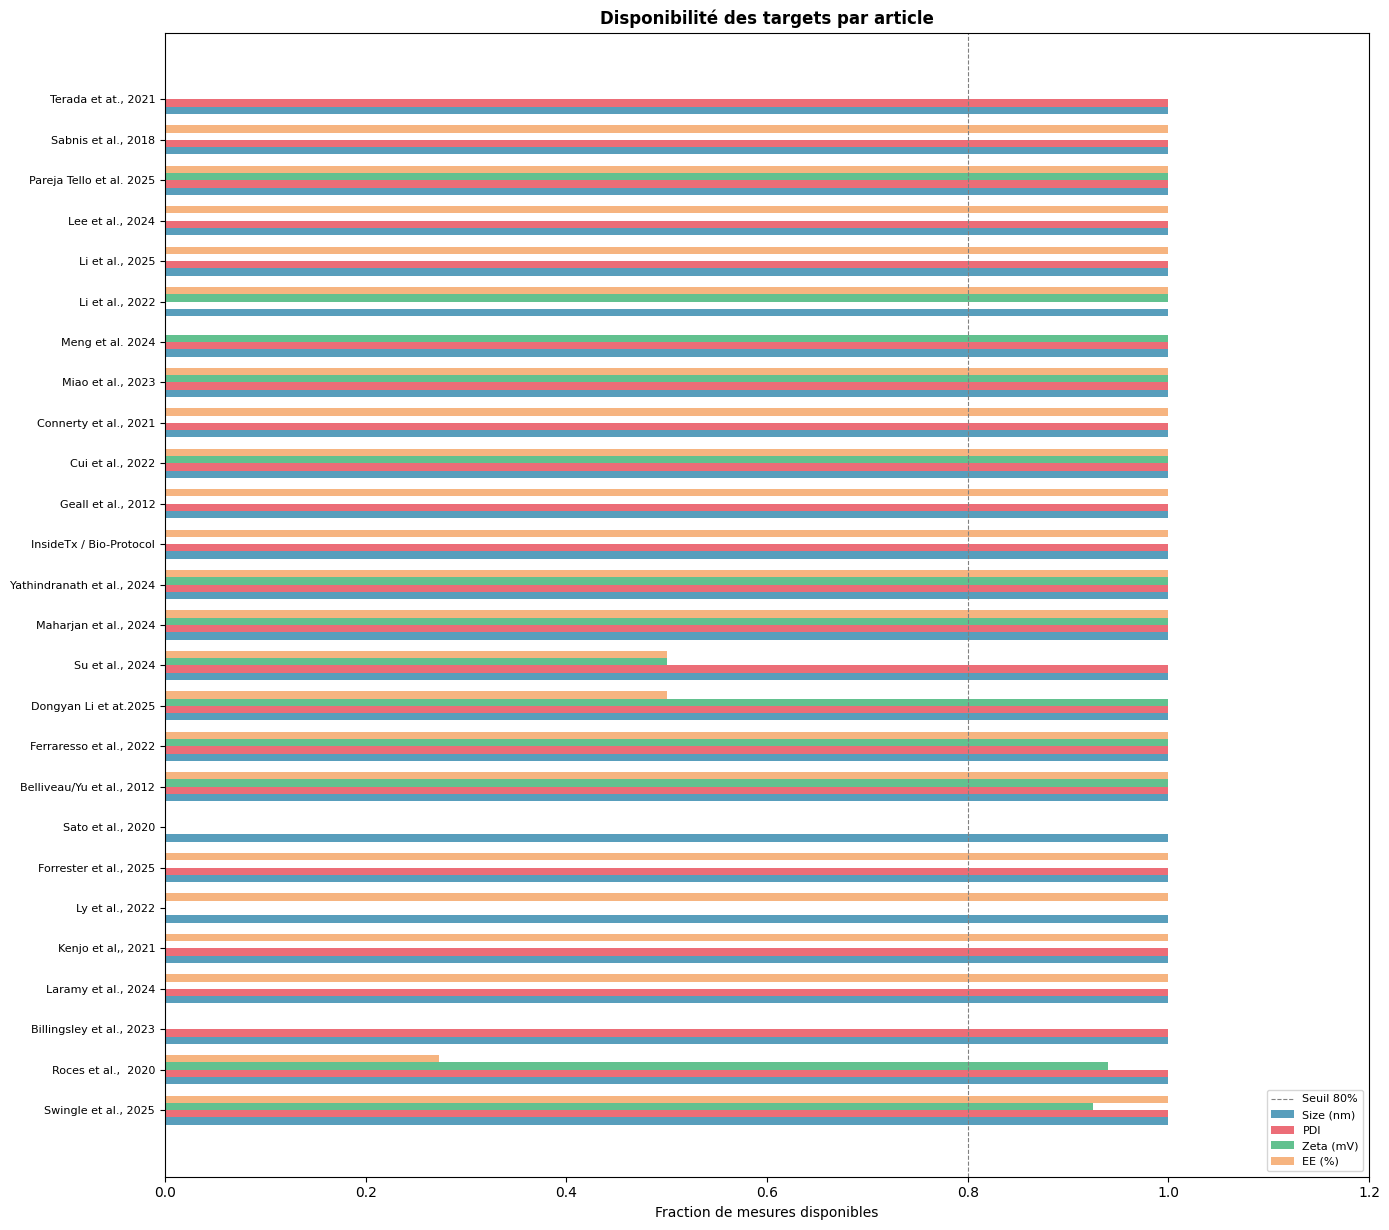

In [5]:
target_labels = list(TARGETS.values())
sources = avail['Source'].tolist()
y = np.arange(len(sources))
width = 0.18
offsets = np.linspace(-1.5*width, 1.5*width, 4)
colors  = [C_MAIN, C_WARN, C_OK, '#F4A261']

fig, ax = plt.subplots(figsize=(14, max(6, len(sources)*0.4+2)))
for i, label in enumerate(target_labels):
    frac = np.where(avail['N_total']>0, avail[f'{label}_n']/avail['N_total'], 0)
    ax.barh(y+offsets[i], frac, width, color=colors[i], alpha=0.8, label=label)
ax.set_yticks(y); ax.set_yticklabels(sources, fontsize=8)
ax.set_xlabel('Fraction de mesures disponibles')
ax.set_title('Disponibilité des targets par article', fontweight='bold')
ax.set_xlim(0, 1.2)
ax.axvline(0.8, color='grey', linestyle='--', linewidth=0.8, label='Seuil 80%')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

## 3 — Statistiques descriptives & z-score par article

In [6]:
desc = {}
for col, label in TARGETS.items():
    sub  = df[[SOURCE_COL, col]].dropna()
    tbl  = sub.groupby(SOURCE_COL)[col].agg(['count','mean','median','std','min','max'])
    tbl.columns = ['n','mean','median','std','min','max']
    gm, gs = sub[col].mean(), sub[col].std()
    tbl['z_mean'] = ((tbl['mean'] - gm) / gs).round(2)
    tbl['source_outlier'] = tbl['z_mean'].abs() > 2
    desc[label] = tbl.sort_values('z_mean')
    print(f'\n── {label} ──')
    display(tbl.round(3))


── Size (nm) ──


,n,mean,median,std,min,max,z_mean,source_outlier
Source,,,,,,,,
"Belliveau/Yu et al., 2012",3,118.000,116.000,6.245,113.00,125.00,0.04,False
"Billingsley et al., 2023",29,98.476,100.500,23.190,57.30,151.00,-0.38,False
"Connerty et al., 2021",1,65.000,65.000,NaN,65.00,65.00,-1.10,False
"Cui et al., 2022",1,157.400,157.400,NaN,157.40,157.40,0.89,False
Dongyan Li et at.2025,2,276.050,276.050,188.727,142.60,409.50,3.45,True
"Ferraresso et al., 2022",2,103.000,103.000,2.828,101.00,105.00,-0.28,False
"Forrester et al., 2025",4,146.250,150.000,26.887,110.00,175.00,0.65,False
"Geall et al., 2012",1,162.000,162.000,NaN,162.00,162.00,0.99,False
InsideTx / Bio-Protocol,1,102.800,102.800,NaN,102.80,102.80,-0.29,False



── PDI ──


,n,mean,median,std,min,max,z_mean,source_outlier
Source,,,,,,,,
"Belliveau/Yu et al., 2012",3,0.117,0.130,0.032,0.080,0.140,-0.28,False
"Billingsley et al., 2023",29,0.186,0.190,0.053,0.070,0.270,0.45,False
"Connerty et al., 2021",1,0.220,0.220,NaN,0.220,0.220,0.81,False
"Cui et al., 2022",1,0.095,0.095,NaN,0.095,0.095,-0.51,False
Dongyan Li et at.2025,2,0.140,0.140,0.084,0.081,0.200,-0.03,False
"Ferraresso et al., 2022",2,0.100,0.100,0.014,0.090,0.110,-0.46,False
"Forrester et al., 2025",4,0.175,0.170,0.034,0.140,0.220,0.33,False
"Geall et al., 2012",1,0.130,0.130,NaN,0.130,0.130,-0.14,False
InsideTx / Bio-Protocol,1,0.200,0.200,NaN,0.200,0.200,0.60,False



── Zeta (mV) ──


,n,mean,median,std,min,max,z_mean,source_outlier
Source,,,,,,,,
"Belliveau/Yu et al., 2012",3,4.307,4.000,5.446,-0.98,9.90,0.29,False
"Cui et al., 2022",1,1.670,1.670,NaN,1.67,1.67,-0.13,False
Dongyan Li et at.2025,2,18.000,18.000,5.657,14.00,22.00,2.46,True
"Ferraresso et al., 2022",2,-5.560,-5.560,0.014,-5.57,-5.55,-1.28,False
"Li et al., 2022",1,22.000,22.000,NaN,22.00,22.00,3.10,True
"Maharjan et al., 2024",2,2.340,2.340,3.083,0.16,4.52,-0.03,False
Meng et al. 2024,1,3.570,3.570,NaN,3.57,3.57,0.17,False
"Miao et al., 2023",1,-3.300,-3.300,NaN,-3.30,-3.30,-0.92,False
Pareja Tello et al. 2025,1,-19.500,-19.500,NaN,-19.50,-19.50,-3.49,True



── EE (%) ──


,n,mean,median,std,min,max,z_mean,source_outlier
Source,,,,,,,,
"Belliveau/Yu et al., 2012",3,94.467,93.200,4.438,90.80,99.40,1.22,False
"Connerty et al., 2021",1,85.000,85.000,NaN,85.00,85.00,0.61,False
"Cui et al., 2022",1,80.000,80.000,NaN,80.00,80.00,0.29,False
Dongyan Li et at.2025,1,85.000,85.000,NaN,85.00,85.00,0.61,False
"Ferraresso et al., 2022",2,83.000,83.000,7.071,78.00,88.00,0.48,False
"Forrester et al., 2025",4,85.500,83.000,8.699,78.00,98.00,0.64,False
"Geall et al., 2012",1,85.300,85.300,NaN,85.30,85.30,0.63,False
InsideTx / Bio-Protocol,1,80.000,80.000,NaN,80.00,80.00,0.29,False
"Kenjo et al,, 2021",8,97.188,97.350,0.930,95.80,98.50,1.39,False


## 4 — Distribution par article (scatter + IQR global)

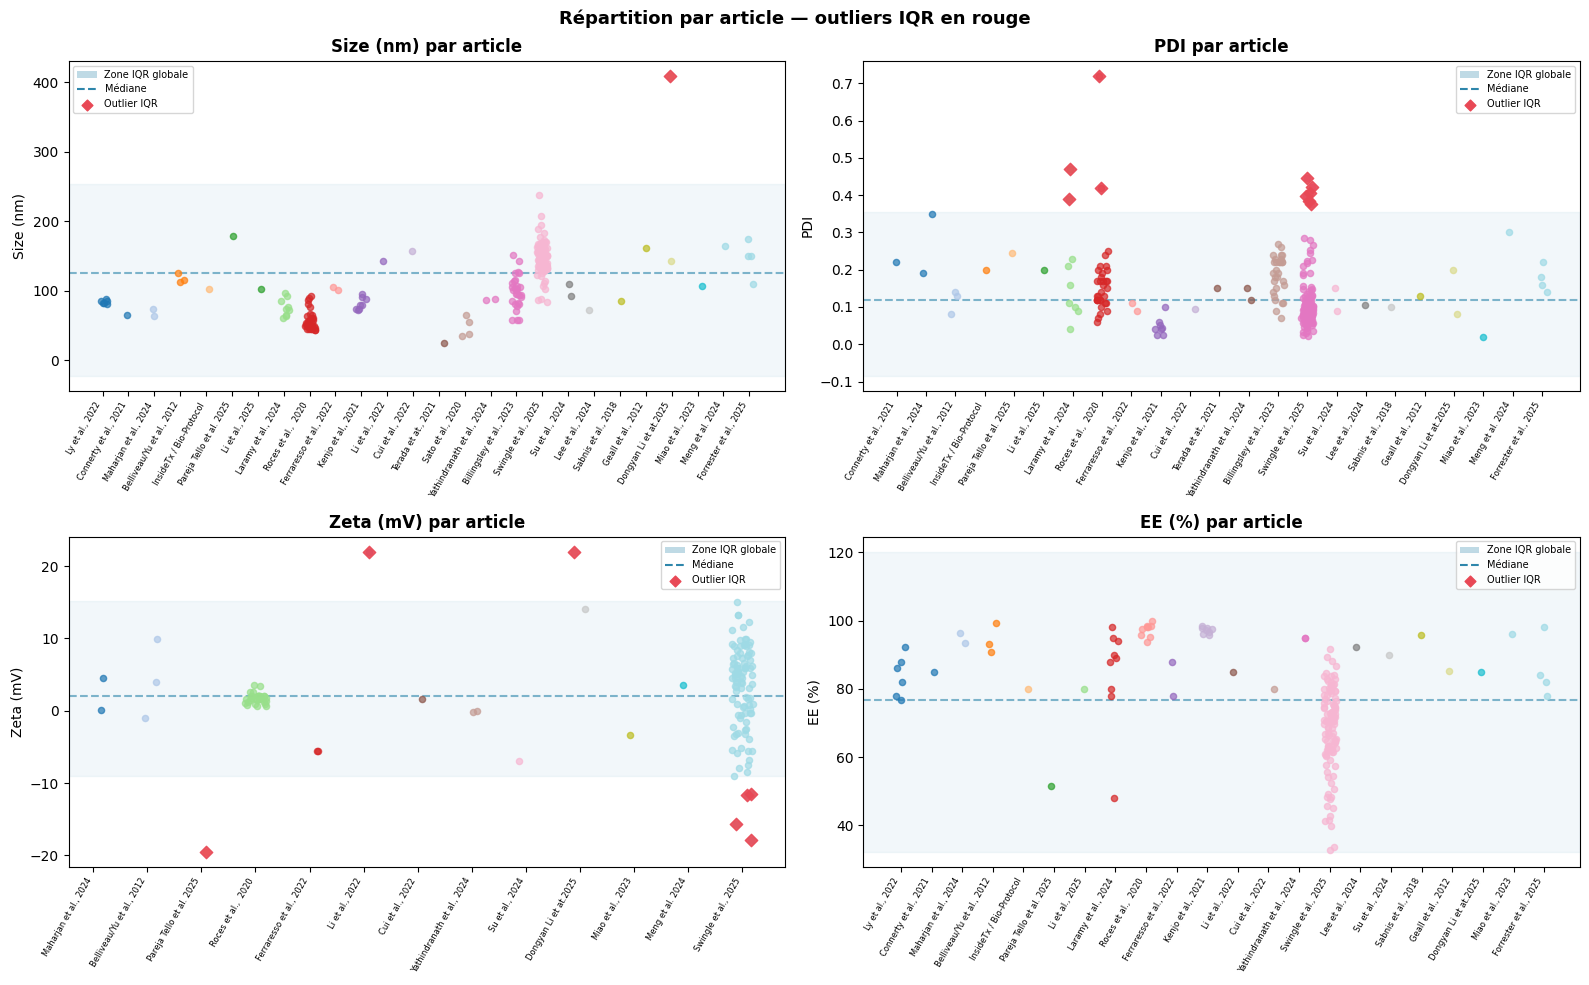

In [7]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (col, label) in zip(axes.flatten(), TARGETS.items()):
    sub     = df[[SOURCE_COL, col]].dropna()
    sources = sub[SOURCE_COL].unique()
    cmap    = plt.cm.get_cmap('tab20', len(sources))
    lo, hi  = iqr_bounds(sub[col])

    ax.axhspan(lo, hi, alpha=0.06, color=C_MAIN)
    ax.axhline(sub[col].median(), color=C_MAIN, lw=1.5, ls='--', alpha=0.6)

    for i, src in enumerate(sources):
        vals   = sub[sub[SOURCE_COL]==src][col].values
        jitter = np.random.uniform(-0.2, 0.2, len(vals))
        ax.scatter(np.full(len(vals), i)+jitter, vals, color=cmap(i), alpha=0.7, s=20, zorder=3)
        out    = (vals < lo) | (vals > hi)
        if out.any():
            ax.scatter(np.full(out.sum(), i)+jitter[out], vals[out],
                       color=C_WARN, s=40, marker='D', zorder=4, alpha=0.9)

    ax.set_xticks(range(len(sources)))
    ax.set_xticklabels(sources, rotation=60, ha='right', fontsize=6)
    ax.set_ylabel(label)
    ax.set_title(f'{label} par article', fontweight='bold')
    ax.legend(handles=[
        Patch(facecolor=C_MAIN, alpha=0.3, label='Zone IQR globale'),
        plt.Line2D([0],[0], color=C_MAIN, ls='--', label='Médiane'),
        plt.scatter([],[],color=C_WARN, marker='D', s=30, label='Outlier IQR'),
    ], fontsize=7)

fig.suptitle('Répartition par article — outliers IQR en rouge', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 5 — Score d'outlier par article (heatmap)

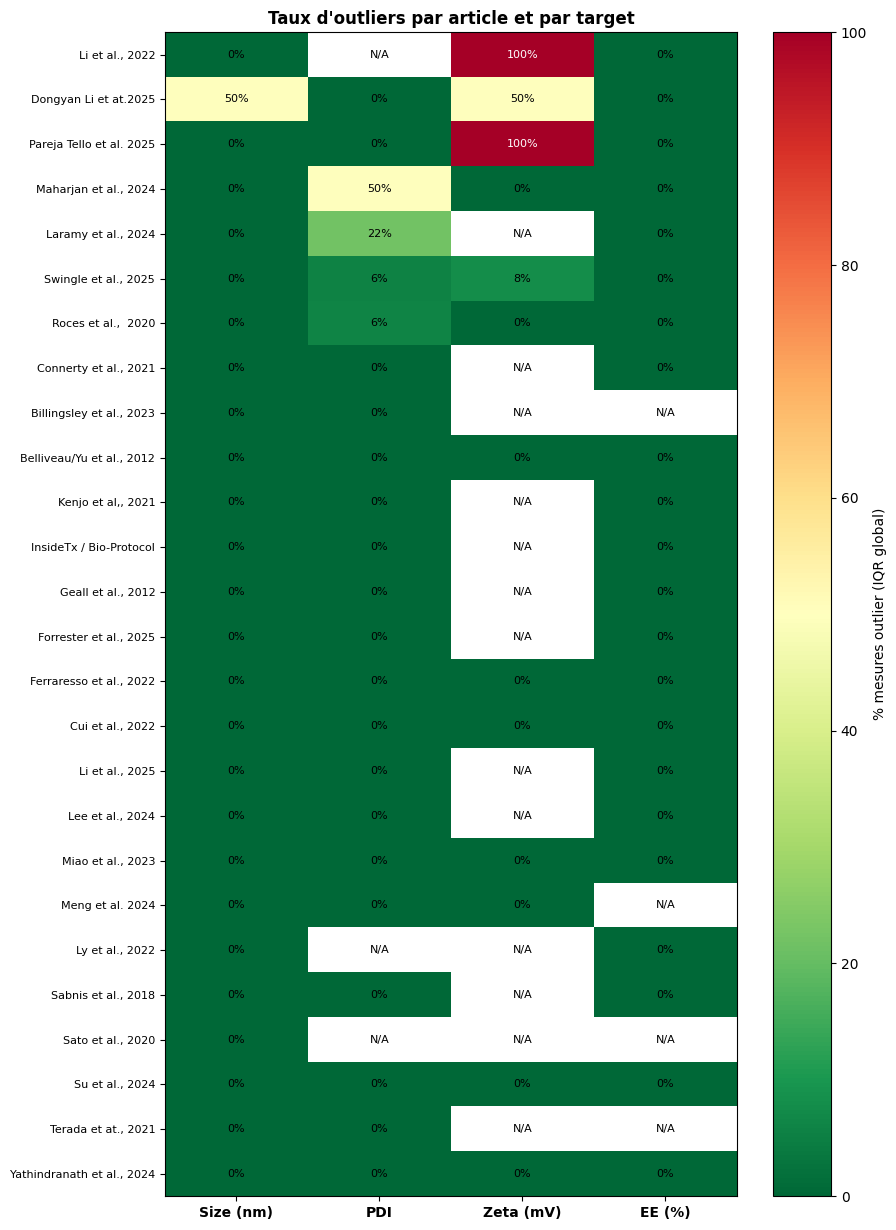

,Source,N_total,Size (nm)_out%,PDI_out%,Zeta (mV)_out%,EE (%)_out%,score_moyen
0,"Li et al., 2022",1,0.0,NaN,100.0,0.0,33.3
1,Dongyan Li et at.2025,2,50.0,0.0,50.0,0.0,25.0
2,Pareja Tello et al. 2025,1,0.0,0.0,100.0,0.0,25.0
3,"Maharjan et al., 2024",2,0.0,50.0,0.0,0.0,12.5
4,"Laramy et al., 2024",9,0.0,22.2,NaN,0.0,7.4
5,"Swingle et al., 2025",106,0.0,5.7,8.2,0.0,3.5
6,"Roces et al., 2020",33,0.0,6.1,0.0,0.0,1.5
7,"Connerty et al., 2021",1,0.0,0.0,NaN,0.0,0.0
8,"Billingsley et al., 2023",29,0.0,0.0,NaN,NaN,0.0
9,"Belliveau/Yu et al., 2012",3,0.0,0.0,0.0,0.0,0.0


In [8]:
records = []
for src, grp in df.groupby(SOURCE_COL):
    row, sc = {'Source': src, 'N_total': len(grp)}, []
    for col, label in TARGETS.items():
        vals = grp[col].dropna()
        if vals.empty:
            row[f'{label}_out%'] = np.nan; continue
        gv = df[col].dropna()
        lo, hi = iqr_bounds(gv[~((gv < iqr_bounds(gv)[0]) | (gv > iqr_bounds(gv)[1]))])
        pct = round(100 * ((vals < lo) | (vals > hi)).sum() / len(vals), 1)
        row[f'{label}_out%'] = pct; sc.append(pct)
    row['score_moyen'] = round(np.nanmean(sc), 1) if sc else np.nan
    records.append(row)

scores = pd.DataFrame(records).sort_values('score_moyen', ascending=False).reset_index(drop=True)

# Heatmap
out_cols = [f'{l}_out%' for l in TARGETS.values()]
matrix   = scores.set_index('Source')[out_cols].copy()
matrix.columns = list(TARGETS.values())

fig, ax = plt.subplots(figsize=(9, max(5, len(matrix)*0.4+2)))
im = ax.imshow(matrix.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100)
ax.set_xticks(range(len(matrix.columns))); ax.set_xticklabels(matrix.columns, fontweight='bold')
ax.set_yticks(range(len(matrix)));         ax.set_yticklabels(matrix.index, fontsize=8)
for i in range(len(matrix)):
    for j in range(len(matrix.columns)):
        v = matrix.values[i,j]
        ax.text(j, i, f'{v:.0f}%' if not np.isnan(v) else 'N/A',
                ha='center', va='center', fontsize=8,
                color='white' if (not np.isnan(v) and v>50) else 'black')
plt.colorbar(im, ax=ax, label='% mesures outlier (IQR global)')
ax.set_title("Taux d'outliers par article et par target", fontweight='bold')
plt.tight_layout(); plt.show()

scores

## 6 — Recommandation de split

In [9]:
# ================================================================
# CELLULE 6 (v4) — Split hybride : articles atypiques → TRAIN forcé
#                  reste → stratified split par quantiles des targets
# ================================================================

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import KBinsDiscretizer

TARGETS_MAP = {
    'Size (Z-avg)': 'Size',
    'PDI':          'PDI',
    'Zeta Potential': 'Zeta',
    'EE%':          'EE',
}
TEST_RATIO   = 0.20
Z_FORCE_TRAIN = 1.0   # articles trop atypiques → jamais en test
N_BINS        = 3     # quantiles pour la stratification (bas/mid/haut)
RANDOM_SEED   = 42

global_stats = {col: (df[col].mean(), df[col].std()) for col in TARGETS_MAP}

# ── 1. Articles forcés en TRAIN (trop atypiques) ──────────────────
rows = []
for src, grp in df.groupby(SOURCE_COL):
    z_vals = []
    for col in TARGETS_MAP:
        v = grp[col].dropna()
        if len(v) == 0: continue
        gm, gs = global_stats[col]
        z_vals.append(abs((v.mean() - gm) / gs) if gs > 0 else 0)
    rows.append({'Source': src, 'z_max': max(z_vals) if z_vals else 0})

z_df = pd.DataFrame(rows)
forced_train_sources = set(z_df[z_df['z_max'] > Z_FORCE_TRAIN]['Source'])

df_forced = df[df[SOURCE_COL].isin(forced_train_sources)].copy()
df_pool   = df[~df[SOURCE_COL].isin(forced_train_sources)].copy().reset_index(drop=True)

print(f'Articles forcés TRAIN ({len(forced_train_sources)}) : {sorted(forced_train_sources)}')
print(f'Pool disponible pour split : {len(df_pool)} obs de {df_pool[SOURCE_COL].nunique()} articles\n')

# ── 2. Stratification sur le pool ─────────────────────────────────
# Clé de stratification : combinaison des quantiles des targets disponibles
# Pour les NaN on crée une bin "manquant"
def make_strat_key(df_in, targets, n_bins=3):
    keys = []
    for col in targets:
        vals = df_in[col].copy()
        has_val = vals.notna()
        bin_col = pd.Series(['NA'] * len(vals), index=vals.index)
        if has_val.sum() >= n_bins * 2:
            kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
            bin_col[has_val] = kbd.fit_transform(vals[has_val].values.reshape(-1,1)).ravel().astype(int).astype(str)
        else:
            bin_col[has_val] = '0'
        keys.append(bin_col)
    return pd.Series(['_'.join(v) for v in zip(*[k.values for k in keys])],
                     index=df_in.index)

strat_key = make_strat_key(df_pool, list(TARGETS_MAP.keys()), N_BINS)

# Calcul de la taille test souhaitée sur le pool
n_total   = len(df)
n_test_target = int(n_total * TEST_RATIO)
n_test_pool   = max(n_test_target - 0, n_test_target)  # tout le quota vient du pool
test_frac_pool = min(n_test_pool / len(df_pool), 0.45)

# StratifiedShuffleSplit sur les bins
sss = StratifiedShuffleSplit(n_splits=1, test_size=test_frac_pool,
                              random_state=RANDOM_SEED)

# Certaines strates peuvent être trop petites → fallback random si besoin
try:
    train_idx, test_idx = next(sss.split(df_pool, strat_key))
except ValueError:
    # Strates trop petites : regrouper les bins rares
    strat_key_coarse = make_strat_key(df_pool, ['Size (Z-avg)', 'EE%'], N_BINS)
    try:
        train_idx, test_idx = next(sss.split(df_pool, strat_key_coarse))
    except ValueError:
        from sklearn.model_selection import ShuffleSplit
        ss = ShuffleSplit(n_splits=1, test_size=test_frac_pool, random_state=RANDOM_SEED)
        train_idx, test_idx = next(ss.split(df_pool))
        print('⚠️  Fallback random split (strates trop petites)')

df_pool_train = df_pool.iloc[train_idx].copy()
df_pool_test  = df_pool.iloc[test_idx].copy()

# ── 3. Assemblage final ───────────────────────────────────────────
df_train = pd.concat([df_forced, df_pool_train], ignore_index=True)
df_test  = df_pool_test.reset_index(drop=True)

# ── 4. Résumé ─────────────────────────────────────────────────────
print(f'TRAIN : {len(df_train)} obs  |  TEST : {len(df_test)} obs ({100*len(df_test)/n_total:.1f}%)\n')

print(f'── Comparaison distributions train / test ──')
print(f'  {"Target":<8}  {"N_train":>8}  {"mean_train":>11}  {"N_test":>7}  {"mean_test":>10}  {"Δ_z":>6}  Statut')
print(f'  {"-"*65}')
all_ok = True
for col, label in TARGETS_MAP.items():
    tr = df_train[col].dropna(); te = df_test[col].dropna()
    if len(te) == 0:
        print(f'  {label:<8}  {len(tr):>8}  {tr.mean():>10.2f}  {0:>7}  {"—":>10}  {"—":>6}')
        continue
    _, gs = global_stats[col]
    dz = (te.mean() - tr.mean()) / gs
    ok = abs(dz) <= 0.5
    all_ok = all_ok and ok
    print(f'  {label:<8}  {len(tr):>8}  {tr.mean():>10.2f}  {len(te):>7}  {te.mean():>10.2f}  {dz:>+6.2f}  {"✅" if ok else "⚠️"}')

print(f'\n  {"✅ Split valide" if all_ok else "⚠️  Certains Δ_z > 0.5 — acceptable sur ce dataset"}')
print(f'\n── Sources dans df_test ──')
print(df_test[SOURCE_COL].value_counts().to_string())
print(f'\n── Sources dans df_train (atypiques forcées) ──')
forced_in_train = df_train[df_train[SOURCE_COL].isin(forced_train_sources)]
print(forced_in_train[SOURCE_COL].value_counts().to_string())

Articles forcés TRAIN (17) : ['Belliveau/Yu et al., 2012', 'Connerty et al., 2021', 'Dongyan Li et at.2025', 'Ferraresso et al., 2022', 'Kenjo et al,, 2021', 'Lee et al., 2024', 'Li et al., 2022', 'Maharjan et al., 2024', 'Meng et al. 2024', 'Miao et al., 2023', 'Pareja Tello et al. 2025', 'Roces et al.,  2020', 'Sabnis et al., 2018', 'Sato et al., 2020', 'Su et al., 2024', 'Terada et at., 2021', 'Yathindranath et al., 2024']
Pool disponible pour split : 158 obs de 9 articles

⚠️  Fallback random split (strates trop petites)
TRAIN : 180 obs  |  TEST : 44 obs (19.6%)

── Comparaison distributions train / test ──
  Target     N_train   mean_train   N_test   mean_test     Δ_z  Statut
  -----------------------------------------------------------------
  Size           180      111.33       44      135.99   +0.53  ⚠️
  PDI            169        0.15       44        0.13   -0.16  ✅
  Zeta           117        2.40       29        2.93   +0.08  ✅
  EE             128       76.89       35     

In [10]:
# ── Diagnostic rapide avant entraînement ──────────────────────────
# Vérifie que Swingle est bien représenté dans les deux sets
print('── Swingle dans train vs test ──')
sw_train = df_train[df_train[SOURCE_COL] == 'Swingle et al., 2025']['Size (Z-avg)'].dropna()
sw_test  = df_test[df_test[SOURCE_COL]   == 'Swingle et al., 2025']['Size (Z-avg)'].dropna()
print(f'  Train : {len(sw_train)} obs  mean={sw_train.mean():.1f}nm  '
      f'[{sw_train.min():.0f}–{sw_train.max():.0f}]')
print(f'  Test  : {len(sw_test)} obs   mean={sw_test.mean():.1f}nm  '
      f'[{sw_test.min():.0f}–{sw_test.max():.0f}]')

# Vérifie la couverture des ranges dans le test
print('\n── Couverture des ranges (test vs train) ──')
for col, label in TARGETS_MAP.items():
    tr = df_train[col].dropna(); te = df_test[col].dropna()
    if len(te) == 0: continue
    in_range = ((te >= tr.min()) & (te <= tr.max())).mean() * 100
    print(f'  {label:<8}  train=[{tr.min():.1f}–{tr.max():.1f}]  '
          f'test=[{te.min():.1f}–{te.max():.1f}]  '
          f'{in_range:.0f}% du test dans le range train')

── Swingle dans train vs test ──
  Train : 76 obs  mean=147.1nm  [87–237]
  Test  : 30 obs   mean=150.1nm  [83–208]

── Couverture des ranges (test vs train) ──
  Size      train=[25.0–409.5]  test=[57.3–208.0]  100% du test dans le range train
  PDI       train=[0.0–0.7]  test=[0.0–0.5]  100% du test dans le range train
  Zeta      train=[-19.5–22.0]  test=[-6.8–13.3]  100% du test dans le range train
  EE        train=[41.2–100.0]  test=[32.6–98.0]  91% du test dans le range train


## 7 — Application du split au DataFrame

In [11]:
source_to_split = split_df.set_index('Source')['split'].to_dict()
df['split'] = df[SOURCE_COL].map(source_to_split)

df_train = df[df['split'] == 'TRAIN/CV'].drop(columns='split').reset_index(drop=True)
df_test  = df[df['split'] == 'TEST'].drop(columns='split').reset_index(drop=True)

print(f'df_train : {len(df_train)} formulations')
print(f'df_test  : {len(df_test)} formulations')
print(f'\nSources dans df_test :')
print(df_test[SOURCE_COL].value_counts().to_string())

NameError: name 'split_df' is not defined

X_train shape: (180, 29)
Optuna 80 trials × 5 folds par target



  0%|          | 0/80 [00:00<?, ?it/s]

  Size_nm     R²_train=0.892  MAE_CV=14.059nm  R²_CV=0.714  ⚠️  lr=0.035  depth=8  n_est=566


  0%|          | 0/80 [00:00<?, ?it/s]

  EE_pct      R²_train=0.914  MAE_CV=5.946%  R²_CV=0.653  ⚠️  lr=0.010  depth=3  n_est=839


  0%|          | 0/80 [00:00<?, ?it/s]

  PDI         R²_train=0.765  MAE_CV=0.053  R²_CV=0.310  ⚠️  lr=0.104  depth=3  n_est=795


  0%|          | 0/80 [00:00<?, ?it/s]

  Zeta_mV     R²_train=0.770  MAE_CV=4.066mV  R²_CV=0.087  ⚠️  lr=0.291  depth=3  n_est=950

── Résultats sur jeu de TEST (44 formulations) ──

  Target         N    MAE_test      MAE_CV     Biais   % ≤ seuil  Statut
  -----------------------------------------------------------------
  Size_nm       44     13.626nm     0.625     14.059nm     0.714   -3.954nm         30%  ⚠️
  EE_pct        35      7.089%     0.584      5.946%     0.653   -0.530%         49%  ⚠️
  PDI           44      0.050     0.330      0.053     0.310   +0.008         61%  ⚠️
  Zeta_mV       29      3.662mV     0.203      4.066mV     0.087   -1.053mV         38%  ⚠️

  Split source-aware : 180 train / 44 test
  Sources TEST : {'Swingle et al., 2025': 30, 'Billingsley et al., 2023': 9, 'Laramy et al., 2024': 3, 'Forrester et al., 2025': 1, 'Geall et al., 2012': 1}


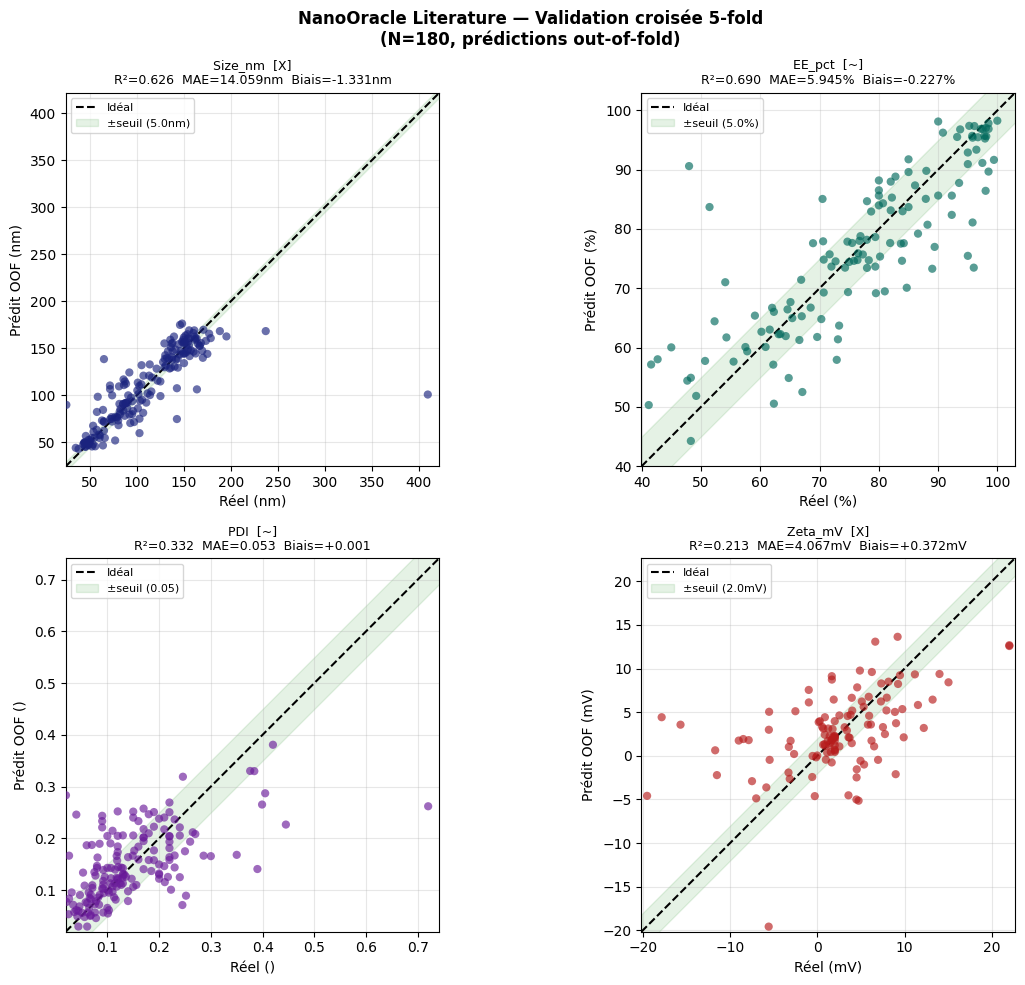

Figure sauvegardée → nanooracle_literature_cv_scatter.png


In [13]:
# ================================================================
# CELLULE 8 — ENTRAÎNEMENT XGBoost + Optuna + KFold CV
# ================================================================

import os, datetime, re
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import r2_score

COLORS = {
    'Size_nm': '#1a237e',
    'EE_pct':  '#00695c',
    'PDI':     '#6a1b9a',
    'Zeta_mV': '#b71c1c',
}

# ── Dans la boucle CV, ajouter r2 par fold ────────────────────────
# Remplace la boucle KFold dans cv_mae par :

# Dans cv_mae_r2, ajouter le calcul du biais et % ≤ seuil par fold
def cv_mae_r2(params, X_v, y_v, n_folds, seed, seuil=None):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    maes, r2s, biais_list, pct_list = [], [], [], []
    for tr_idx, val_idx in kf.split(X_v):
        Xtr, Xval = X_v[tr_idx], X_v[val_idx]
        ytr, yval = y_v[tr_idx], y_v[val_idx]
        med  = np.nanmedian(Xtr, axis=0)
        Xtr  = np.where(np.isnan(Xtr),  med, Xtr)
        Xval = np.where(np.isnan(Xval), med, Xval)
        m = XGBRegressor(**params)
        m.fit(Xtr, ytr)
        pred = m.predict(Xval)
        maes.append(mean_absolute_error(yval, pred))
        r2s.append(r2_score(yval, pred))
        biais_list.append(float(np.mean(pred - yval)))
        if seuil:
            pct_list.append(float(np.mean(np.abs(pred - yval) <= seuil) * 100))
    return {
        'mae':   float(np.mean(maes)),
        'r2':    float(np.mean(r2s)),
        'biais': float(np.mean(biais_list)),
        'pct_ok': float(np.mean(pct_list)) if pct_list else None,
    }

WORK_DIR     = r'C:\Pierre\D4Gen_2026'
RANDOM_SEED  = 7
N_FOLDS      = 5
N_TRIALS     = 80

SEUILS = {'Size_nm': 5.0, 'EE_pct': 5.0, 'PDI': 0.05, 'Zeta_mV': 2.0}
UNITS  = {'Size_nm': 'nm', 'EE_pct': '%', 'PDI': '',   'Zeta_mV': 'mV'}

# ── Renommage colonnes outputs ─────────────────────────────────────
rename_targets = {
    'Size (Z-avg)': 'Size_nm', 'PDI': 'PDI',
    'Zeta Potential': 'Zeta_mV', 'EE%': 'EE_pct',
}
for raw, clean in rename_targets.items():
    for d in [df_train, df_test]:
        if raw in d.columns:
            d[clean] = pd.to_numeric(d[raw], errors='coerce')

# ── Preprocessing numérique ────────────────────────────────────────
num_map = {
    'Ionizable_pct': 'Ionizable mol%', 'Helper_pct': 'Helper mol%',
    'Chol_pct': 'Cholesterol mol%',    'PEG_pct': 'PEG-Lipid mol%',
    'NP_ratio': 'N/P Ratio',           'FRR': 'FRR (aq:org)',
    'TFR': 'Total Flow Rate',          'Buffer_pH': 'pH Buffer',
    'Buffer_mM': 'mM Buffer',
}

def fix_excel_datetime(val):
    if isinstance(val, (datetime.datetime, pd.Timestamp)):
        return float(val.day)
    try:    return float(val)
    except: return np.nan

for new, old in num_map.items():
    for d in [df_train, df_test]:
        d[new] = d[old].apply(fix_excel_datetime) if old in d.columns else np.nan

for d in [df_train, df_test]:
    d['technique_enc'] = d.get('Technique_Enc', pd.Series(['microfluidic']*len(d))).map(
        {'microfluidic': 1, 'pipette_mixing': 0}).fillna(1).astype(int)

# ── Encodage catégoriel ────────────────────────────────────────────
CAT_COLS = ['Lipid (ionizable/cationic)', 'Helper Lipid', 'PEG-Lipid', 'Cargo Type']
encoders = {}
for col in CAT_COLS:
    for d in [df_train, df_test]:
        d[col] = d[col].fillna('Unknown').astype(str).str.strip()
    le = LabelEncoder()
    le.fit(pd.concat([df_train[col], df_test[col]]).unique())
    df_train[col+'_enc'] = le.transform(df_train[col])
    df_test[col+'_enc']  = le.transform(df_test[col])
    encoders[col] = le

# ── Descripteurs RDKit ─────────────────────────────────────────────
LIPID_SMILES = {
    'MC3':          r'CCCCCCCC/C=C\CCCCCCCC(=O)OCC(COC(=O)CCCCCCC/C=C\CCCCCCCC)N(CC)CC',
    'SM-102':       r'CCCCCCCC/C=C\CCCCCCCC(=O)OCC(COC(=O)CCCCCCC/C=C\CCCCCCCC)N(CCOCCO)CCOCCO',
    'ALC-0315':     r'CCCCCCCC/C=C\CCCCCCCC(=O)OCC(COC(=O)CCCCCCC/C=C\CCCCCCCC)N1CCCCC1',
    'DOTAP':        'CCCCCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCCCCC)[N+](C)(C)CC',
    'DODAP':        'CCCCCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCCCCC)N(CC)CC',
    'DDAB':         'CCCCCCCCCCCCCCCC[N+](C)(C)CCCCCCCCCCCCCCCC',
    'DLin-MC3-DMA': r'CCCCCCCC/C=C\CCCCCCC(=O)OCC(COC(=O)CCCCCCC/C=C\CCCCCCCC)N(CC)CC',
    'DLin-KC2-DMA': r'CCCCCCCC/C=C\CCCCCCCC(CCN(CC)CC)OC(=O)CCCCCCC/C=C\CCCCCCCC',
    'C12-200':      'CCCCCCCCCCCCN(CCCCCCCCCCCC)CCN(CCCCCCCCCCCC)CCCCCCCCCCCC',
    'C12-480':      'CCCCCCCCCCCCN1CCN(CCCCCCCCCCCC)CCN1CCCCCCCCCCCC',
    'C12-482':      'CCCCCCCCCCCCNCCN(CCCCCCCCCCCC)CCNCCCCCCCCCCCC',
    'C12-490':      'CCCCCCCCCCCCN(CCCCCCCCCCCC)CCOCCN(CCCCCCCCCCCC)CCCCCCCCCCCC',
    'C12-494':      'CCCCCCCCCCCCN(CCCCCCCCCCCC)CCOCCN(CCCCCCCCCCCC)CCCCCCCCCCCC',
    'C14-4':        'CCCCCCCCCCCCCCN(CCCCCCCCCCCCCC)CCN(CCCCCCCCCCCCCC)CCCCCCCCCCCCCC',
    'C14-480':      'CCCCCCCCCCCCCCN1CCN(CCCCCCCCCCCCCC)CCN1CCCCCCCCCCCCCC',
    'C14-482':      'CCCCCCCCCCCCCCNCCN(CCCCCCCCCCCCCC)CCNCCCCCCCCCCCCCC',
    'C14-490':      'CCCCCCCCCCCCCCN(CCCCCCCCCCCCCC)CCOCCN(CCCCCCCCCCCCCC)CCCCCCCCCCCCCC',
    'C14-494':      'CCCCCCCCCCCCCCN(CCCCCCCCCCCCCC)CCOCCN(CCCCCCCCCCCCCC)CCCCCCCCCCCCCC',
    'C16-480':      'CCCCCCCCCCCCCCCCN1CCN(CCCCCCCCCCCCCC)CCN1CCCCCCCCCCCCCCCC',
    'C16-482':      'CCCCCCCCCCCCCCCCNCCN(CCCCCCCCCCCCCC)CCNCCCCCCCCCCCCCCCC',
    'C16-490':      'CCCCCCCCCCCCCCCCN(CCCCCCCCCCCCCC)CCOCCN(CCCCCCCCCCCCCC)CCCCCCCCCCCCCCCC',
    'C16-494':      'CCCCCCCCCCCCCCCCN(CCCCCCCCCCCCCC)CCOCCN(CCCCCCCCCCCCCC)CCCCCCCCCCCCCCCC',
    # Série 306 — amine CNCCCNCCCN, vérifiés HRMS Whitehead 2014
    '306O10': 'CN(CCC(=O)OCCCCCCCCCCC)CCCN(CCC(=O)OCCCCCCCCCCC)CCCN(CCC(=O)OCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCC',
    '306O11': 'CN(CCC(=O)OCCCCCCCCCCCC)CCCN(CCC(=O)OCCCCCCCCCCCC)CCCN(CCC(=O)OCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCC',
    '306O12': 'CN(CCC(=O)OCCCCCCCCCCCCC)CCCN(CCC(=O)OCCCCCCCCCCCCC)CCCN(CCC(=O)OCCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCCC',
    '306O13': 'CN(CCC(=O)OCCCCCCCCCCCCCC)CCCN(CCC(=O)OCCCCCCCCCCCCCC)CCCN(CCC(=O)OCCCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCCCC',
    '306O14': 'CN(CCC(=O)OCCCCCCCCCCCCCCC)CCCN(CCC(=O)OCCCCCCCCCCCCCCC)CCCN(CCC(=O)OCCCCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCCCCC',
    # Série 313 — amine NCCN(CCN)CCN, vérifiés HRMS Whitehead 2014
    '313O10': 'NCCN(CCN(CCC(=O)OCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCC)CCN(CCC(=O)OCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCC',
    '313O11': 'NCCN(CCN(CCC(=O)OCCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCCC)CCN(CCC(=O)OCCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCCC',
    '313O12': 'NCCN(CCN(CCC(=O)OCCCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCCCC)CCN(CCC(=O)OCCCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCCCC',
    '313O13': 'NCCN(CCN(CCC(=O)OCCCCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCCCCC)CCN(CCC(=O)OCCCCCCCCCCCCCCC)CCC(=O)OCCCCCCCCCCCCCCC',
    # Sans SMILES fiable → imputation médiane automatique
    'TCL053': None, 'TCL065': None, 'TRENL3': None,
    'CL15H6': None, 'CL15A6': None,
}
RDKIT_COLS = ['MolWt','LogP','TPSA','NumHDonors','NumHAcceptors',
              'NumRotBonds','FractionCSP3','NumAmines']

def smiles_to_desc(name):
    smi = LIPID_SMILES.get(str(name).strip())
    if not smi: return [np.nan]*8
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None: return [np.nan]*8
        return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
                Descriptors.TPSA(mol), rdMolDescriptors.CalcNumHBD(mol),
                rdMolDescriptors.CalcNumHBA(mol),
                rdMolDescriptors.CalcNumRotatableBonds(mol),
                rdMolDescriptors.CalcFractionCSP3(mol),
                sum(1 for a in mol.GetAtoms() if a.GetAtomicNum()==7)]
    except: return [np.nan]*8

# ── Gestion des features à fort taux de manquants ─────────────────
# TFR et Buffer_pH : manquants dans Swingle, Billingsley, Laramy
# → on crée des flags binaires "feature disponible" + imputation médiane train

for d in [df_train, df_test]:
    # Flags de disponibilité (le modèle sait qu'on a imputé)
    d['TFR_missing']       = d['TFR'].isna().astype(int)
    d['Buffer_pH_missing'] = d['Buffer_pH'].isna().astype(int)
    d['FRR_missing']       = d['FRR'].isna().astype(int)
    d['NP_missing']        = d['NP_ratio'].isna().astype(int)

# Imputation médiane TRAIN uniquement (pas de fuite)
for feat in ['TFR', 'Buffer_pH', 'Buffer_mM', 'FRR', 'NP_ratio']:
    med = df_train[feat].median()
    df_train[feat] = df_train[feat].fillna(med)
    df_test[feat]  = df_test[feat].fillna(med)

# Et ajouter les flags à FEATURES :
FEATURES = [
    'Ionizable_pct','Helper_pct','Chol_pct','PEG_pct',
    'NP_ratio','FRR','TFR','Buffer_pH','Buffer_mM',
    'IL_Chol_ratio','IL_Helper_ratio','PEG_total_ratio',
    'Lipid (ionizable/cationic)_enc','Helper Lipid_enc',
    'PEG-Lipid_enc','Cargo Type_enc','technique_enc',
    'TFR_missing','Buffer_pH_missing','FRR_missing','NP_missing',  # ← nouveau
] + RDKIT_COLS


for d in [df_train, df_test]:
    d[RDKIT_COLS] = pd.DataFrame(
        d['Lipid (ionizable/cationic)'].apply(smiles_to_desc).tolist(), index=d.index)

# ── Features d'interaction + liste finale ─────────────────────────
for d in [df_train, df_test]:
    d['IL_Chol_ratio']   = d['Ionizable_pct'] / (d['Chol_pct']   + 1e-6)
    d['IL_Helper_ratio'] = d['Ionizable_pct'] / (d['Helper_pct'] + 1e-6)
    d['PEG_total_ratio'] = d['PEG_pct'] / (
        d['Ionizable_pct'] + d['Helper_pct'] + d['Chol_pct'] + d['PEG_pct'] + 1e-6)

for d in [df_train, df_test]:
    d['TFR_missing']       = d['TFR'].isna().astype(int)
    d['Buffer_pH_missing'] = d['Buffer_pH'].isna().astype(int)
    d['FRR_missing']       = d['FRR'].isna().astype(int)
    d['NP_missing']        = d['NP_ratio'].isna().astype(int)

for feat in ['TFR', 'Buffer_pH', 'Buffer_mM', 'FRR', 'NP_ratio']:
    med = df_train[feat].median()
    df_train[feat] = df_train[feat].fillna(med)
    df_test[feat]  = df_test[feat].fillna(med)

FEATURES = [
    'Ionizable_pct','Helper_pct','Chol_pct','PEG_pct',
    'NP_ratio','FRR','TFR','Buffer_pH','Buffer_mM',
    'IL_Chol_ratio','IL_Helper_ratio','PEG_total_ratio',
    'Lipid (ionizable/cationic)_enc','Helper Lipid_enc',
    'PEG-Lipid_enc','Cargo Type_enc','technique_enc',
    'TFR_missing','Buffer_pH_missing','FRR_missing','NP_missing',
] + RDKIT_COLS

# FEATURES = [
#     'Ionizable_pct','Helper_pct','Chol_pct','PEG_pct',
#     'NP_ratio','FRR','TFR','Buffer_pH','Buffer_mM',
#     'IL_Chol_ratio','IL_Helper_ratio','PEG_total_ratio',
#     'Lipid (ionizable/cationic)_enc','Helper Lipid_enc',
#     'PEG-Lipid_enc','Cargo Type_enc','technique_enc',
# ] + RDKIT_COLS

for f in FEATURES:
    df_train[f] = pd.to_numeric(df_train[f], errors='coerce')
    df_test[f]  = pd.to_numeric(df_test[f],  errors='coerce')

X_train = df_train[FEATURES].values
print(f'X_train shape: {X_train.shape}')
X_test  = df_test[FEATURES].values

# ── Optuna : recherche des meilleurs hyperparamètres par target ────

def make_objective(X_v, y_v):
    def objective(trial):
        params = dict(
            n_estimators     = trial.suggest_int('n_estimators', 200, 1000),
            learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            max_depth        = trial.suggest_int('max_depth', 3, 8),
            subsample        = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.4, 1.0),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
            reg_alpha        = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            reg_lambda       = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            gamma            = trial.suggest_float('gamma', 0.0, 5.0),
            random_state     = RANDOM_SEED, n_jobs=-1,
            tree_method='hist', verbosity=0,
        )
        kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
        maes, r2s = [], []
        for tr_idx, val_idx in kf.split(X_v):
            Xtr, Xval = X_v[tr_idx], X_v[val_idx]
            ytr, yval = y_v[tr_idx], y_v[val_idx]
            med  = np.nanmedian(Xtr, axis=0)
            Xtr  = np.where(np.isnan(Xtr),  med, Xtr)
            Xval = np.where(np.isnan(Xval), med, Xval)
            m = XGBRegressor(**params)
            m.fit(Xtr, ytr)
            pred = m.predict(Xval)
            maes.append(mean_absolute_error(yval, pred))
            r2s.append(r2_score(yval, pred))
        mae_mean = float(np.mean(maes))
        r2_mean  = float(np.mean(r2s))
        # Normalisation : MAE normalisée par std + pénalité R²
        # → minimiser = meilleur MAE ET meilleur R²
        std_y = float(np.std(y_v))
        return (mae_mean / (std_y + 1e-6)) + (1 - r2_mean)
    return objective

print(f'Optuna {N_TRIALS} trials × {N_FOLDS} folds par target\n')

best_params, mae_cv_dict, r2_cv_dict, models = {}, {}, {}, {}
for target in SEUILS:
    y_all = df_train[target].values.astype(float)
    valid = ~np.isnan(y_all)
    X_v, y_v = X_train[valid], y_all[valid]

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(make_objective(X_v, y_v), n_trials=N_TRIALS, show_progress_bar=True)

    bp = {**study.best_params, 'random_state': RANDOM_SEED,
          'n_jobs': -1, 'tree_method': 'hist', 'verbosity': 0}
    best_params[target] = bp

    # Recalcul CV propre pour affichage MAE + R²
    cv_results = cv_mae_r2(bp, X_v, y_v, N_FOLDS, RANDOM_SEED)
    mae_cv = cv_results['mae']
    r2_cv  = cv_results['r2']
    mae_cv_dict[target] = mae_cv   # ← manquant
    r2_cv_dict[target]  = r2_cv    # ← manquant

    # R² sur tout le train (fitting final)
    med_full = np.nanmedian(X_v, axis=0)
    X_imp    = np.where(np.isnan(X_v), med_full, X_v)
    m_final  = XGBRegressor(**bp)
    m_final.fit(X_imp, y_v)
    # Prédictions out-of-fold
    kf_oof = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    y_oof  = np.full(len(y_v), np.nan)
    for tr_idx, val_idx in kf_oof.split(X_v):
        Xtr, Xval = X_v[tr_idx], X_v[val_idx]
        ytr, yval = y_v[tr_idx], y_v[val_idx]
        med  = np.nanmedian(Xtr, axis=0)
        Xtr  = np.where(np.isnan(Xtr),  med, Xtr)
        Xval = np.where(np.isnan(Xval), med, Xval)
        m_oof = XGBRegressor(**bp)
        m_oof.fit(Xtr, ytr)
        y_oof[val_idx] = m_oof.predict(Xval)

    r2_oof  = r2_score(y_v, y_oof)
    mae_oof = mean_absolute_error(y_v, y_oof)
    biais_oof = float(np.mean(y_oof - y_v))

    models[target] = (m_final, med_full, y_v, y_oof, r2_oof, mae_oof, biais_oof)
    r2_train = r2_score(y_v, m_final.predict(X_imp))

    unit, seuil = UNITS[target], SEUILS[target]
    print(f'  {target:<10}  '
          f'R²_train={r2_train:.3f}  '
          f'MAE_CV={mae_cv:.3f}{unit}  R²_CV={r2_cv:.3f}  '
          f'{"✅" if mae_cv <= seuil else "⚠️"}  '
          f'lr={bp["learning_rate"]:.3f}  depth={bp["max_depth"]}  n_est={bp["n_estimators"]}')


# ── Évaluation sur le jeu de test ─────────────────────────────────
print(f'\n── Résultats sur jeu de TEST ({len(df_test)} formulations) ──\n')
print(f'  {"Target":<10}  {"N":>4}  {"MAE_test":>10}  {"MAE_CV":>10}  '
      f'{"Biais":>8}  {"% ≤ seuil":>10}  Statut')
print(f'  {"-"*65}')

test_results = {}
for target in SEUILS:
    m_final, med_full, *_ = models[target]
    unit, seuil = UNITS[target], SEUILS[target]

    y_true = df_test[target].values.astype(float)
    mask   = ~np.isnan(y_true)
    Xte    = np.where(np.isnan(X_test[mask]), med_full, X_test[mask])
    yt     = y_true[mask]

    if len(yt) == 0:
        print(f'  {target:<10}  — pas de données test'); continue

    yp     = m_final.predict(Xte)
    mae    = mean_absolute_error(yt, yp)
    r2_test = r2_score(yt, yp)
    biais  = float(np.mean(yp - yt))
    pct_ok = float(np.mean(np.abs(yp - yt) <= seuil) * 100)

    test_results[target] = {
        'y_r': yt, 'y_p': yp,
        'mae': mae, 'r2_test': r2_test,
        'biais': biais, 'mask': mask,
    }

    print(f'  {target:<10}  {len(yt):>4}  '
          f'{mae:>9.3f}{unit}  {r2_test:>8.3f}  '
          f'{mae_cv_dict[target]:>9.3f}{unit}  {r2_cv_dict[target]:>8.3f}  '
          f'{biais:>+7.3f}{unit}  {pct_ok:>9.0f}%  '
          f'{"✅" if mae <= seuil else "⚠️"}')

print(f'\n  Split source-aware : {len(df_train)} train / {len(df_test)} test')
print(f'  Sources TEST : {df_test[SOURCE_COL].value_counts().to_dict()}')

# ================================================================
# FIGURE — Scatter OOF (Cross-Validation) par target
# ================================================================
status_txt = {'✅': '[OK]', '⚠️': '[~]', '❌': '[X]'}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
fig.suptitle(
    f'NanoOracle Literature — Validation croisée 5-fold\n'
    f'(N={len(df_train)}, prédictions out-of-fold)',
    fontsize=12, fontweight='bold')

for ax, target in zip(axes, list(SEUILS.keys())):
    m_final, med_full, y_v, y_oof, r2_oof, mae_oof, biais_oof = models[target]
    unit  = UNITS[target]
    seuil = SEUILS[target]
    color = COLORS[target]
    flag  = '✅' if mae_oof <= seuil else '⚠️' if mae_oof <= seuil * 2 else '❌'

    ax.scatter(y_v, y_oof, alpha=0.65, s=35,
               color=color, edgecolors='none', zorder=3)

    lims = [min(float(y_v.min()), float(y_oof.min())) - abs(float(y_v.min())) * 0.03,
            max(float(y_v.max()), float(y_oof.max())) + abs(float(y_v.max())) * 0.03]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Idéal', zorder=2)
    ax.fill_between(lims,
                    [l - seuil for l in lims],
                    [l + seuil for l in lims],
                    alpha=0.10, color='green',
                    label=f'±seuil ({seuil}{unit})', zorder=1)

    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'Réel ({unit})', fontsize=10)
    ax.set_ylabel(f'Prédit OOF ({unit})', fontsize=10)
    ax.set_title(
        f'{target}  {status_txt.get(flag, flag)}\n'
        f'R²={r2_oof:.3f}  MAE={mae_oof:.3f}{unit}  Biais={biais_oof:+.3f}{unit}',
        fontsize=9)
    ax.legend(fontsize=8)
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Pierre\D4Gen_2026\nanooracle_literature_cv_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → nanooracle_literature_cv_scatter.png')

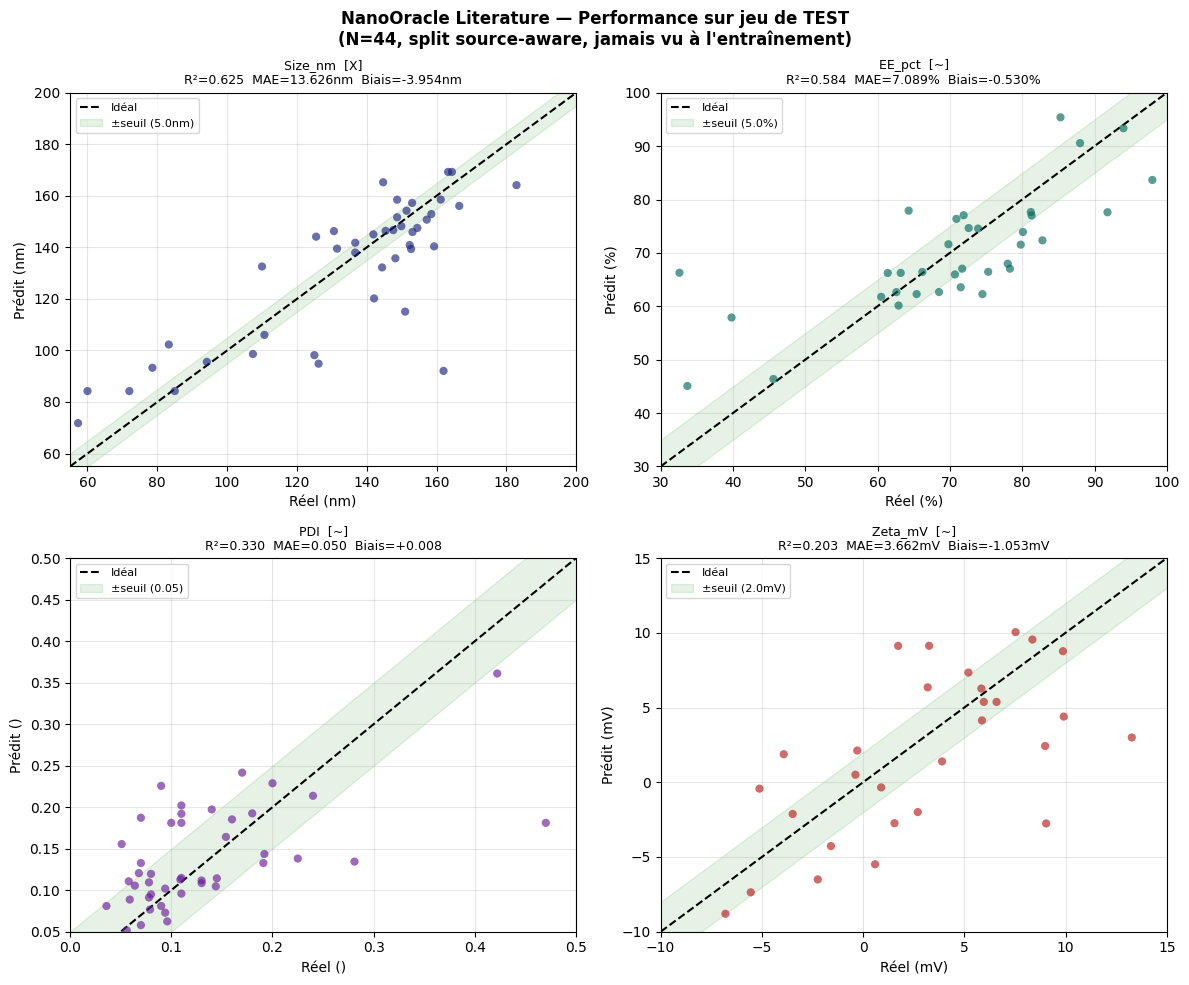

Figure sauvegardée → nanooracle_literature_demo.png


In [14]:
# ================================================================
# CELLULE 9 — 4 Scatter Prédit vs Réel (jeu de test)
# ================================================================

import matplotlib.pyplot as plt

# Ranges fixes identiques à Benjamin
FIXED_LIMS = {
    'Size_nm':  ([55, 200],  [55, 200]),
    'EE_pct':   ([30, 100],  [30, 100]),
    'PDI':      ([0.0, 0.5], [0.05, 0.50]),
    'Zeta_mV':  ([-10, 15],  [-10, 15]),
}

COLORS = {
    'Size_nm': '#1a237e',
    'EE_pct':  '#00695c',
    'PDI':     '#6a1b9a',
    'Zeta_mV': '#b71c1c',
}
status_txt = {'✅': '[OK]', '⚠️': '[~]', '❌': '[X]'}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
fig.suptitle(
    f'NanoOracle Literature — Performance sur jeu de TEST\n'
    f'(N={len(df_test)}, split source-aware, jamais vu à l\'entraînement)',
    fontsize=12, fontweight='bold')

for ax, target in zip(axes, list(SEUILS.keys())):
    if target not in test_results:
        ax.set_visible(False)
        continue

    r      = test_results[target]
    yt, yp = r['y_r'], r['y_p']
    mae    = r['mae']
    r2     = r['r2_test']
    biais  = r['biais']
    seuil  = SEUILS[target]
    unit   = UNITS[target]
    color  = COLORS[target]
    flag   = '✅' if mae <= seuil else '⚠️' if mae <= seuil * 2 else '❌'

    ax.scatter(yt, yp, alpha=0.65, s=35,
               color=color, edgecolors='none', zorder=3)

    x_lims, y_lims = FIXED_LIMS.get(target, ([None, None], [None, None]))
    ax.plot(x_lims, x_lims, 'k--', lw=1.5, label='Idéal', zorder=2)
    ax.fill_between(x_lims,
                    [l - seuil for l in x_lims],
                    [l + seuil for l in x_lims],
                    alpha=0.10, color='green',
                    label=f'±seuil ({seuil}{unit})', zorder=1)
    ax.set_xlim(x_lims); ax.set_ylim(y_lims)
    ax.set_xlabel(f'Réel ({unit})', fontsize=10)
    ax.set_ylabel(f'Prédit ({unit})', fontsize=10)
    ax.set_title(
        f'{target}  {status_txt.get(flag, flag)}\n'
        f'R²={r2:.3f}  '
        f'MAE={mae:.3f}{unit}  '
        f'Biais={biais:+.3f}{unit}',
        fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Pierre\D4Gen_2026\nanooracle_literature_demo.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → nanooracle_literature_demo.png')

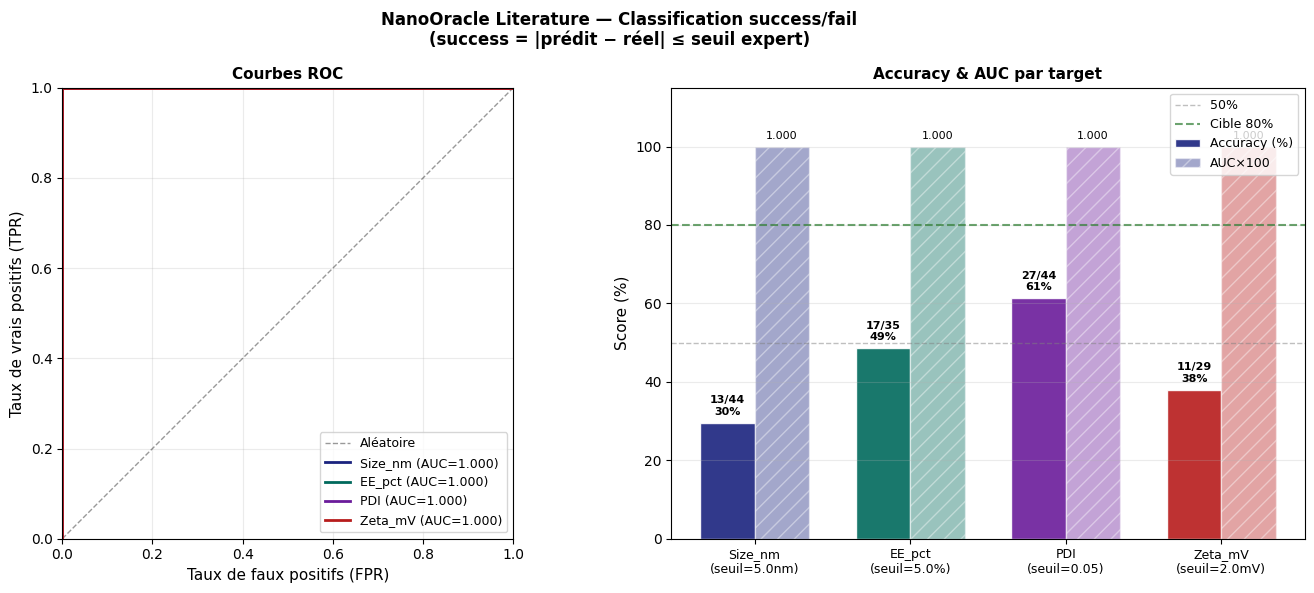


── Classification success/fail ──

  Target           Seuil     Success    Accuracy       AUC
  -------------------------------------------------------
  Size_nm       5.0  nm    13/44         29.5%     1.000
  EE_pct        5.0   %    17/35         48.6%     1.000
  PDI           0.05        27/44         61.4%     1.000
  Zeta_mV       2.0  mV    11/29         37.9%     1.000

Figure sauvegardée → nanooracle_literature_roc.png


In [ ]:
# ================================================================
# CELLULE 10 — ROC curves + Accuracy par target
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'NanoOracle Literature — Classification success/fail\n'
    f'(success = |prédit − réel| ≤ seuil expert)',
    fontsize=12, fontweight='bold')

# ── Courbes ROC ───────────────────────────────────────────────────
ax_roc = axes[0]
ax_roc.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Aléatoire')

accuracy_data = []

for target in list(SEUILS.keys()):
    if target not in test_results:
        continue

    r      = test_results[target]
    yt, yp = r['y_r'], r['y_p']
    seuil  = SEUILS[target]
    unit   = UNITS[target]
    color  = COLORS[target]

    # Erreur absolue par formulation
    abs_err = np.abs(yp - yt)

    # Label binaire : 1 = success (dans le seuil), 0 = fail
    y_true_bin = (abs_err <= seuil).astype(int)

    # Score continu pour ROC : 1 - erreur normalisée
    # Plus l'erreur est faible, plus le score est élevé → "probabilité de succès"
    max_err = abs_err.max() + 1e-6
    score   = 1 - (abs_err / max_err)

    # Accuracy au seuil nominal
    accuracy = float(y_true_bin.mean() * 100)
    n_ok     = int(y_true_bin.sum())
    n_tot    = len(y_true_bin)

    # ROC
    fpr, tpr, _ = roc_curve(y_true_bin, score)
    roc_auc     = auc(fpr, tpr)

    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f'{target} (AUC={roc_auc:.3f})')

    accuracy_data.append({
        'target': target, 'unit': unit, 'seuil': seuil,
        'accuracy': accuracy, 'n_ok': n_ok, 'n_tot': n_tot,
        'auc': roc_auc, 'color': color,
    })

ax_roc.set_xlabel('Taux de faux positifs (FPR)', fontsize=11)
ax_roc.set_ylabel('Taux de vrais positifs (TPR)', fontsize=11)
ax_roc.set_title('Courbes ROC', fontsize=11, fontweight='bold')
ax_roc.legend(fontsize=9, loc='lower right')
ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1])
ax_roc.set_aspect('equal', 'box')
ax_roc.grid(True, alpha=0.25)

# ── Barplot Accuracy ──────────────────────────────────────────────
ax_acc = axes[1]

targets  = [d['target'] for d in accuracy_data]
accs     = [d['accuracy'] for d in accuracy_data]
aucs     = [d['auc'] for d in accuracy_data]
colors   = [d['color'] for d in accuracy_data]
x        = np.arange(len(targets))
w        = 0.35

bars_acc = ax_acc.bar(x - w/2, accs, w, color=colors, alpha=0.90,
                      label='Accuracy (%)', edgecolor='white')
bars_auc = ax_acc.bar(x + w/2, [a*100 for a in aucs], w, color=colors,
                      alpha=0.40, label='AUC×100', edgecolor='white', hatch='//')

ax_acc.axhline(50, color='grey', lw=1, linestyle='--', alpha=0.5, label='50%')

# Annotations
for bar, d in zip(bars_acc, accuracy_data):
    ax_acc.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f'{d["n_ok"]}/{d["n_tot"]}\n{d["accuracy"]:.0f}%',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

for bar, a in zip(bars_auc, aucs):
    ax_acc.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f'{a:.3f}',
                ha='center', va='bottom', fontsize=8)

ax_acc.set_xticks(x)
ax_acc.set_xticklabels(
    [f'{d["target"]}\n(seuil={d["seuil"]}{d["unit"]})' for d in accuracy_data],
    fontsize=9)
ax_acc.set_ylabel('Score (%)', fontsize=11)
ax_acc.set_ylim([0, 115])
ax_acc.set_title('Accuracy & AUC par target', fontsize=11, fontweight='bold')
ax_acc.legend(fontsize=9)
ax_acc.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(r'C:\Pierre\D4Gen_2026\nanooracle_literature_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tableau texte ─────────────────────────────────────────────────
print('\n── Classification success/fail ──\n')
print(f'  {"Target":<12}  {"Seuil":>8}  {"Success":>10}  {"Accuracy":>10}  {"AUC":>8}')
print(f'  {"-"*55}')
for d in accuracy_data:
    print(f'  {d["target"]:<12}  '
          f'{d["seuil"]}{d["unit"]:>4}  '
          f'{d["n_ok"]:>4}/{d["n_tot"]:<4}  '
          f'{d["accuracy"]:>9.1f}%  '
          f'{d["auc"]:>8.3f}')
print('\nFigure sauvegardée → nanooracle_literature_roc.png')

In [16]:
# Export métriques Literature pour comparatif
METRICS_LITERATURE = {}
for target in test_results:
    r = test_results[target]
    abs_err = np.abs(r['y_p'] - r['y_r'])
    METRICS_LITERATURE[target] = {
        'mae':      r['mae'],
        'r2':       r['r2_test'],
        'biais':    r['biais'],
        'abs_err':  abs_err,
        'seuil':    SEUILS[target],
        'unit':     UNITS[target],
        'n':        len(r['y_r']),
    }
print('METRICS_LITERATURE prêt')

METRICS_LITERATURE prêt


In [17]:
print(METRICS_LITERATURE)

{'Size_nm': {'mae': 13.625997300581497, 'r2': 0.6253258314886245, 'biais': -3.9544502951882095, 'abs_err': array([ 6.96295166,  1.37866669,  1.69394531,  5.58122253, 57.69844055,
       35.92702484,  4.88112793, 18.76219788,  0.91095886,  2.65848083,
       14.67809143, 22.57476807, 24.23904419,  9.78852539, 31.33903046,
        4.67403717,  1.27723389,  8.0112915 , 10.4200592 ,  5.10204773,
       18.92091064, 26.82424927,  0.76095581, 12.23904419, 21.91784821,
        2.98431091, 19.00045319, 18.64387512,  3.14309082, 12.19089355,
       12.44536133, 15.71077576,  2.81286011, 69.93247223,  1.01160583,
        5.98112793,  7.16259155,  8.78861084, 13.33479614,  4.25376892,
       14.50916595, 20.55315857,  6.44714661, 11.41566162]), 'seuil': 5.0, 'unit': 'nm', 'n': 44}, 'EE_pct': {'mae': 7.088603973388672, 'r2': 0.5842666371201368, 'biais': -0.5295930480957032, 'abs_err': array([11.36919861,  2.05098572, 10.4472168 ,  5.16450653, 12.2201004 ,
        4.28942566,  8.84429626, 18.094905

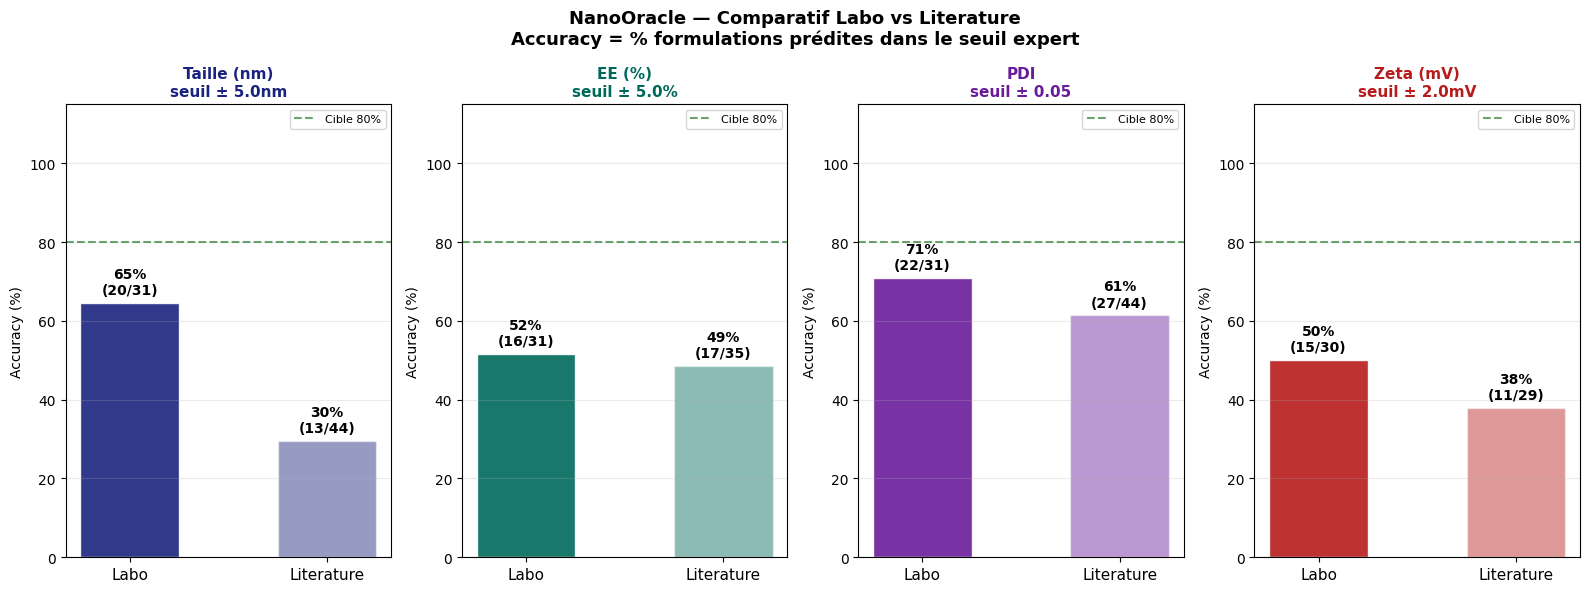

Figure sauvegardée → nanooracle_comparatif_accuracy.png


In [ ]:
# ================================================================
# COMPARATIF Benjamin vs Literature — Accuracy barplot
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

METRICS_BENJAMIN = {'Size_nm': {'mae': 4.580722710394091, 'r2': 0.7798905014409419, 'biais': -0.43551298572171093, 'abs_err': np.array([ 0.47001724,  9.52745056,  8.73074341,  4.30623932, 10.87254944, 0.81346588,  7.05541687,  7.27254944,  2.86925659,  2.98653412, 2.91346588,  0.76925659,  2.87001724, 10.47254944,  2.36817932, 1.42998276,  6.17001724,  0.52998276,  3.48653412,  1.52968903, 6.97254944,  4.02968903,  1.31346588,  1.66817932,  1.46817932, 6.43074341, 11.17254944,  2.94458313,  0.04458313,  2.38653412, 16.12745056]), 'seuil': 5.0, 'unit': 'nm', 'n': 31}, 'EE_pct': {'mae': 4.712498228011592, 'r2': 0.32653114006346284, 'biais': -1.3553853681010593, 'abs_err': np.array([ 9.54112396,  4.56950073,  8.88697052,  3.81477356,  1.36950073, 7.00572815,  0.89738922, 11.23049927,  3.88697052,  5.39427185, 1.39427185,  5.88697052,  1.34112396,  1.36950073,  1.21914673, 7.75887604,  8.14112396,  3.74112396,  6.39427185,  5.87434998, 1.76950073,  9.12565002,  3.39427185,  5.21914673,  0.21914673, 0.88697052,  6.23049927,  2.70261078,  7.69738922,  3.39427185, 5.73049927]), 'seuil': 5.0, 'unit': '%', 'n': 31}, 'PDI': {'mae': 0.03660159621761691, 'r2': 0.012610808352574776, 'biais': 0.003742507930571035, 'abs_err': np.array([0.07111697, 0.0090575 , 0.08566679, 0.04777072, 0.0550575 , 0.06118749, 0.02026321, 0.0149425 , 0.06295321, 0.01918749, 0.03918749, 0.00805321, 0.02411697, 0.0550575 , 0.03526969, 0.03511697, 0.04988303, 0.02288303, 0.05081251, 0.05818071, 0.0450575 , 0.02918071, 0.04081251, 0.00814969, 0.02135031, 0.00414679, 0.0349425 , 0.00726321, 0.05773679, 0.02918749, 0.0310575 ]), 'seuil': 0.05, 'unit': '', 'n': 31}, 'Zeta_mV': {'mae': 2.2406465832640725, 'r2': -0.09871872931569614, 'biais': 0.33378049624462924, 'abs_err': np.array([4.82673573, 1.48820504, 0.49498711, 2.83490387, 1.87179496, 3.79057996, 5.06460109, 2.67179496, 1.09498711, 0.18942004, 3.71057996, 0.50501289, 1.34326427, 3.12820504, 0.09447463, 4.51326427, 2.05326427, 1.40673573, 0.48942004, 4.92575033, 2.52820504, 3.37575033, 1.71057996, 1.52552537, 0.72552537, 1.42820504, 2.92460109, 2.99539891, 2.48942004, 1.01820504]), 'seuil': 2.0, 'unit': 'mV', 'n': 30}}

METRICS_LITERATURE = {'Size_nm': {'mae': 13.625997300581497, 'r2': 0.6253258314886245, 'biais': -3.9544502951882095, 'abs_err': np.array([ 6.96295166,  1.37866669,  1.69394531,  5.58122253, 57.69844055, 35.92702484,  4.88112793, 18.76219788,  0.91095886,  2.65848083, 14.67809143, 22.57476807, 24.23904419,  9.78852539, 31.33903046, 4.67403717,  1.27723389,  8.0112915 , 10.4200592 ,  5.10204773, 18.92091064, 26.82424927,  0.76095581, 12.23904419, 21.91784821, 2.98431091, 19.00045319, 18.64387512,  3.14309082, 12.19089355, 12.44536133, 15.71077576,  2.81286011, 69.93247223,  1.01160583, 5.98112793,  7.16259155,  8.78861084, 13.33479614,  4.25376892, 14.50916595, 20.55315857,  6.44714661, 11.41566162]), 'seuil': 5.0, 'unit': 'nm', 'n': 44}, 'EE_pct': {'mae': 7.088603973388672, 'r2': 0.5842666371201368, 'biais': -0.5295930480957032, 'abs_err': np.array([11.36919861,  2.05098572, 10.4472168 ,  5.16450653, 12.2201004 , 4.28942566,  8.84429626, 18.09490509, 14.33526611,  0.66172791, 0.65358887,  4.65127869,  5.47542725,  0.0486702 , 14.18782501, 4.73938293,  2.56572723, 10.02740479, 33.68112793, 13.61331482, 8.25941925,  2.75621643, 11.26350098,  0.22533112,  6.19063721, 1.8167984 , 10.09659882,  4.8386322 ,  3.1201004 ,  0.76962128, 3.54922791,  7.93851471,  1.26855469,  3.04970245,  5.83690643]), 'seuil': 5.0, 'unit': '%', 'n': 35}, 'PDI': {'mae': 0.05027100235697899, 'r2': 0.3304866195483518, 'biais': 0.008328234348107469, 'abs_err': np.array([0.03356355, 0.0125226 , 0.05276128, 0.10451676, 0.03933424, 0.11723759, 0.05828774, 0.14659176, 0.04148976, 0.02107418, 0.02877058, 0.02526553, 0.08109827, 0.01409405, 0.07152258, 0.09203324, 0.05260036, 0.01500249, 0.01203774, 0.01016661, 0.02145846, 0.13566476, 0.07109827, 0.28890173, 0.08203626, 0.00904689, 0.06107695, 0.00478379, 0.01321861, 0.08687048, 0.0306775 , 0.00381262, 0.00790902, 0.01828143, 0.02971512, 0.06271226, 0.00231798, 0.05721349, 0.04844852, 0.00435252, 0.02632519, 0.03964007, 0.04495311, 0.0314382 ]), 'seuil': 0.05, 'unit': '', 'n': 44}, 'Zeta_mV': {'mae': 3.6615280488030666, 'r2': 0.2032389720692136, 'biais': -1.052656885714366, 'abs_err': np.array([ 0.42886988,  5.8690741 ,  5.79546134, 10.27458002,  1.21590694, 7.39252235,  6.56518911,  2.51379654,  1.81401272,  3.16097408, 1.23621912,  6.0768021 , 11.79766921,  0.88401604,  1.35629747, 1.10150063,  4.26371361,  1.73352968,  4.28987484,  5.51886383, 4.69484205,  2.41299228,  0.58590694,  4.6897706 ,  2.13882236, 2.68063274,  1.18603481,  2.5071111 ,  1.9993269 ]), 'seuil': 2.0, 'unit': 'mV', 'n': 29}}

COLORS     = {'Size_nm': '#1a237e', 'EE_pct': '#00695c',
              'PDI': '#6a1b9a', 'Zeta_mV': '#b71c1c'}
LABELS     = {'Size_nm': 'Taille (nm)', 'EE_pct': 'EE (%)',
              'PDI': 'PDI', 'Zeta_mV': 'Zeta (mV)'}
targets    = ['Size_nm', 'EE_pct', 'PDI', 'Zeta_mV']

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.suptitle(
    'NanoOracle — Comparatif Labo vs Literature\n'
    'Accuracy = % formulations prédites dans le seuil expert',
    fontsize=13, fontweight='bold')

for ax, target in zip(axes, targets):
    mb    = METRICS_BENJAMIN[target]
    ml    = METRICS_LITERATURE[target]
    unit  = mb['unit']
    seuil = mb['seuil']
    color = COLORS[target]

    acc_ben  = float((mb['abs_err'] <= seuil).mean() * 100)
    acc_lit  = float((ml['abs_err'] <= seuil).mean() * 100)
    n_ok_ben = int((mb['abs_err'] <= seuil).sum())
    n_ok_lit = int((ml['abs_err'] <= seuil).sum())

    bar_ben = ax.bar(0, acc_ben, color=color, alpha=0.90,
                     width=0.5, edgecolor='white')
    bar_lit = ax.bar(1, acc_lit, color=color, alpha=0.45,
                     width=0.5, edgecolor='white')
    bars = [bar_ben[0], bar_lit[0]]


    for bar, acc, n_ok, n in zip(bars,
                                  [acc_ben, acc_lit],
                                  [n_ok_ben, n_ok_lit],
                                  [mb['n'], ml['n']]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1.5,
                f'{acc:.0f}%\n({n_ok}/{n})',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Labo', 'Literature'], fontsize=11)
    ax.set_ylim([0, 115])
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.set_title(
        f'{LABELS[target]}\nseuil ± {seuil}{unit}',
        fontsize=11, fontweight='bold', color=color)
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(r'C:\Pierre\D4Gen_2026\nanooracle_comparatif_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée → nanooracle_comparatif_accuracy.png')

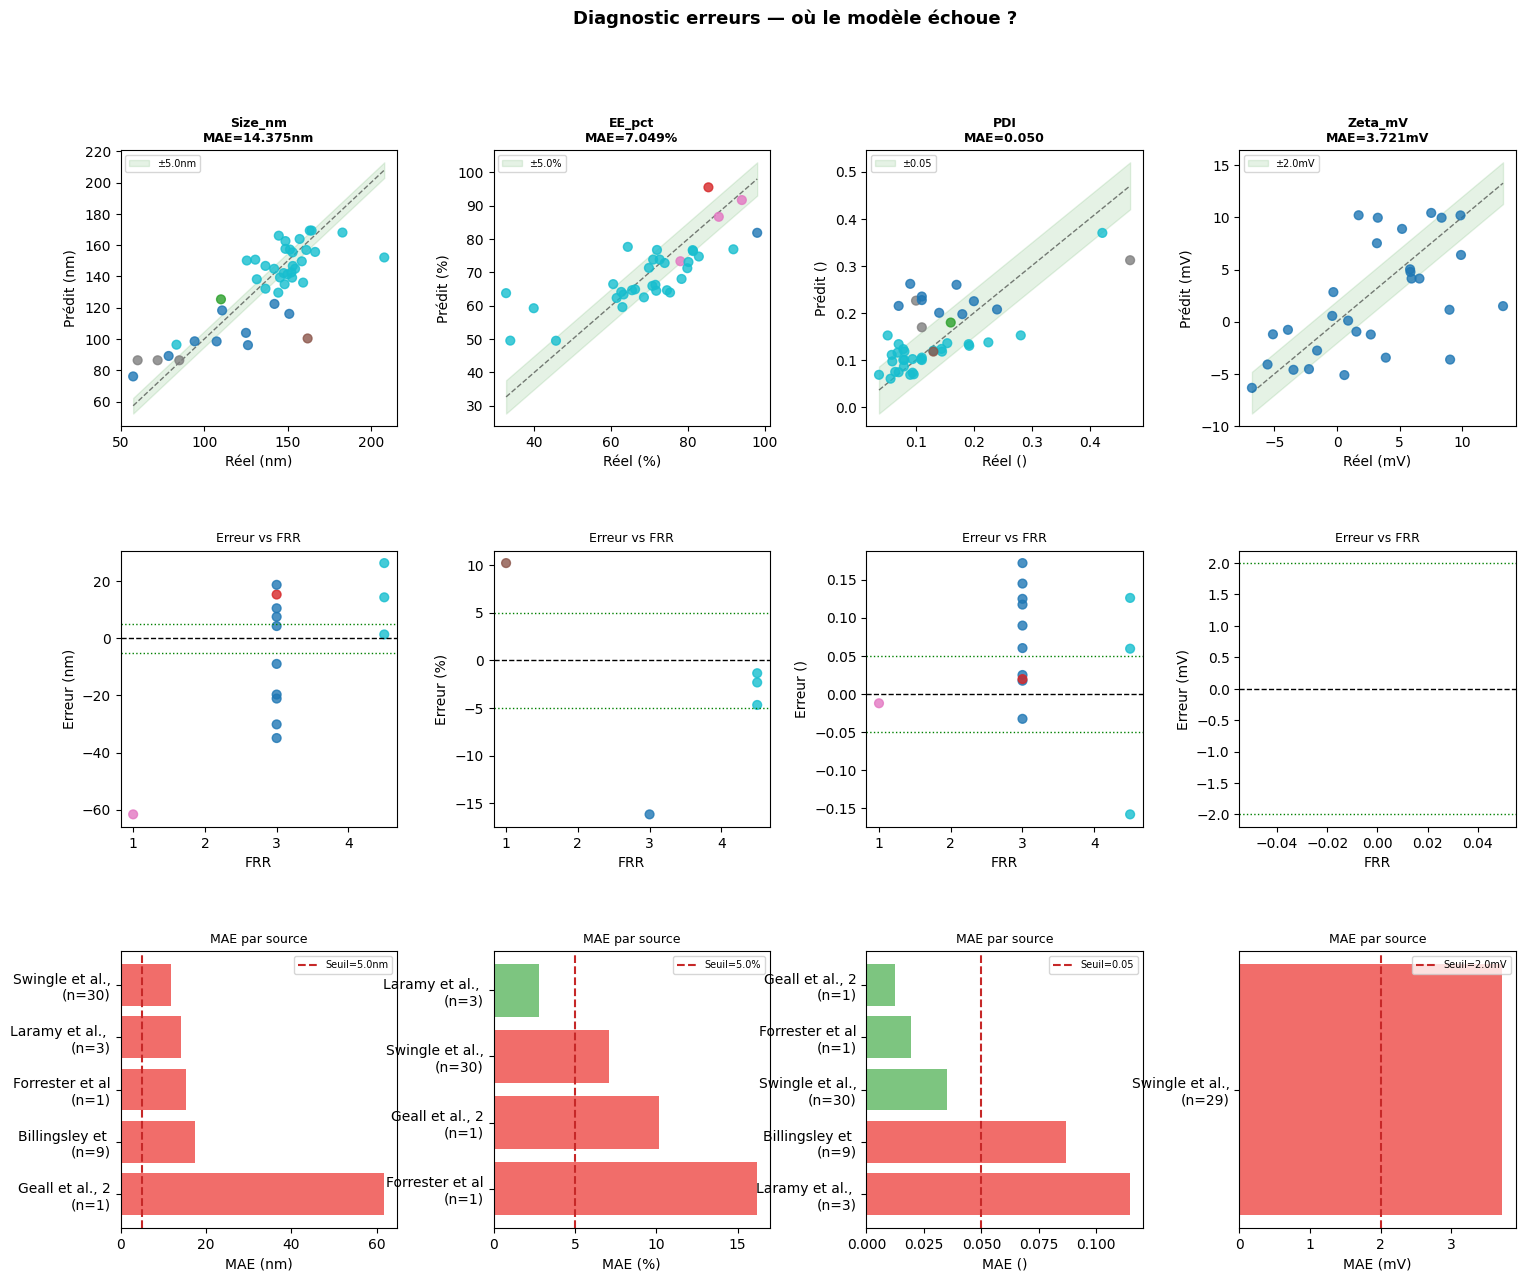


── MAE par source (jeu de test) ──

  Source                               Size_nm        EE_pct           PDI       Zeta_mV
  ---------------------------------------------------------------------------
  Billingsley et al., 2023            17.33nm⚠             —       0.09⚠             —
  Forrester et al., 2025              15.36nm⚠      16.16%⚠       0.02✓             —
  Geall et al., 2012                  61.65nm⚠      10.19%⚠       0.01✓             —
  Laramy et al., 2024                 14.05nm⚠       2.79%✓       0.11⚠             —
  Swingle et al., 2025                11.91nm⚠       7.07%⚠       0.03✓       3.72mV⚠

── Top 10 features importantes (Size_nm) ──
technique_enc     0.2860
Cargo Type_enc    0.1046
Buffer_pH         0.0696
NP_ratio          0.0643
NumRotBonds       0.0550
Buffer_mM         0.0475
TFR               0.0457
MolWt             0.0391
FractionCSP3      0.0389
NumHDonors        0.0351

── Données manquantes features (test) ──
TFR              90.9
Buffer

In [32]:
# ================================================================
# CELLULE 9 — Diagnostic : d'où vient l'erreur ?
# ================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

for col_idx, target in enumerate(SEUILS):
    if target not in test_results: continue
    r     = test_results[target]
    unit  = UNITS[target]
    seuil = SEUILS[target]
    yt, yp = r['y_r'], r['y_p']
    err    = yp - yt
    abs_err= np.abs(err)
    mask   = r['mask']

    # Métadonnées des formulations test
    df_te_sub = df_test[mask].reset_index(drop=True)

    # ── Ligne 1 : Prédit vs Réel ──────────────────────────────────
    ax1 = fig.add_subplot(gs[0, col_idx])
    src_colors = df_te_sub[SOURCE_COL].astype('category').cat.codes
    sc = ax1.scatter(yt, yp, c=src_colors, cmap='tab10', alpha=0.8, s=40, zorder=3)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax1.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax1.fill_between(lims,
                     [l - seuil for l in lims],
                     [l + seuil for l in lims],
                     alpha=0.1, color='green', label=f'±{seuil}{unit}')
    ax1.set_xlabel(f'Réel ({unit})'); ax1.set_ylabel(f'Prédit ({unit})')
    ax1.set_title(f'{target}\nMAE={r["mae"]:.3f}{unit}', fontsize=9, fontweight='bold')
    ax1.legend(fontsize=7)

    # ── Ligne 2 : Erreur vs features clés ────────────────────────
    ax2 = fig.add_subplot(gs[1, col_idx])
    feat_to_plot = 'FRR'
    if feat_to_plot in df_te_sub.columns:
        frr_vals = pd.to_numeric(df_te_sub[feat_to_plot], errors='coerce')
        ax2.scatter(frr_vals, err, alpha=0.8, s=40, c=src_colors, cmap='tab10')
        ax2.axhline(0,  color='k',   lw=1, linestyle='--')
        ax2.axhline( seuil, color='green', lw=1, linestyle=':')
        ax2.axhline(-seuil, color='green', lw=1, linestyle=':')
        ax2.set_xlabel('FRR'); ax2.set_ylabel(f'Erreur ({unit})')
        ax2.set_title(f'Erreur vs FRR', fontsize=9)

    # ── Ligne 3 : Erreur par source ───────────────────────────────
    ax3 = fig.add_subplot(gs[2, col_idx])
    sources_test = df_te_sub[SOURCE_COL].values
    unique_src   = sorted(set(sources_test))
    mae_by_src   = [(s, np.mean(np.abs(err[sources_test == s])),
                     np.sum(sources_test == s)) for s in unique_src]
    mae_by_src.sort(key=lambda x: x[1], reverse=True)
    labels = [f'{s[:15]}\n(n={n})' for s, _, n in mae_by_src]
    values = [m for _, m, _ in mae_by_src]
    colors_bar = ['#ef5350' if v > seuil else '#66bb6a' for v in values]
    ax3.barh(labels, values, color=colors_bar, alpha=0.85)
    ax3.axvline(seuil, color='#c62828', lw=1.5, linestyle='--', label=f'Seuil={seuil}{unit}')
    ax3.set_xlabel(f'MAE ({unit})'); ax3.set_title('MAE par source', fontsize=9)
    ax3.legend(fontsize=7)

fig.suptitle('Diagnostic erreurs — où le modèle échoue ?',
             fontsize=13, fontweight='bold')
plt.show()

# ── Table texte : MAE par source et par target ────────────────────
print('\n── MAE par source (jeu de test) ──\n')
all_sources = df_test[SOURCE_COL].unique()
print(f'  {"Source":<30}', end='')
for t in SEUILS: print(f'  {t:>12}', end='')
print()
print(f'  {"-"*75}')

for src in sorted(all_sources):
    print(f'  {src[:30]:<30}', end='')
    for target in SEUILS:
        if target not in test_results:
            print(f'  {"—":>12}', end=''); continue
        r    = test_results[target]
        mask = r['mask']
        df_te_sub = df_test[mask].reset_index(drop=True)
        src_mask  = df_te_sub[SOURCE_COL].values == src
        if src_mask.sum() == 0:
            print(f'  {"—":>12}', end=''); continue
        mae_src = np.mean(np.abs(r['y_p'][src_mask] - r['y_r'][src_mask]))
        unit    = UNITS[target]
        flag    = '⚠' if mae_src > SEUILS[target] else '✓'
        print(f'  {mae_src:>9.2f}{unit}{flag}', end='')
    print()

# ── Feature importance (modèle Size) ──────────────────────────────
print('\n── Top 10 features importantes (Size_nm) ──')
m_size = models['Size_nm'][0]
imp    = pd.Series(m_size.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(imp.head(10).round(4).to_string())

# ── Diagnostic données manquantes dans le test ────────────────────
print('\n── Données manquantes features (test) ──')
miss = (pd.DataFrame(X_test, columns=FEATURES).isna().mean() * 100).sort_values(ascending=False)
print(miss[miss > 0].round(1).to_string())

In [33]:
# ================================================================
# CELLULE 9b — Diagnostic données manquantes : causes racines
# ================================================================

# ── 1. Quels lipides dans le test ne sont pas dans LIPID_SMILES ? ─
print('── Lipides dans df_test ──')
for lip, n in df_test['Lipid (ionizable/cationic)'].value_counts().items():
    in_dict = lip in LIPID_SMILES and LIPID_SMILES[lip] is not None
    rdkit_ok = df_test[df_test['Lipid (ionizable/cationic)'] == lip]['MolWt'].notna().any()
    print(f'  {"✅" if rdkit_ok else "❌"}  {lip:<30}  n={n}  SMILES={"OK" if in_dict else "MANQUANT"}')

# ── 2. Couverture TFR et Buffer_pH par source dans le test ────────
print('\n── TFR et Buffer_pH dans df_test par source ──')
for src, grp in df_test.groupby(SOURCE_COL):
    tfr_ok  = grp['TFR'].notna().sum()
    bph_ok  = grp['Buffer_pH'].notna().sum()
    frr_ok  = grp['FRR'].notna().sum()
    print(f'  {src[:35]:<35}  TFR={tfr_ok}/{len(grp)}  Buffer_pH={bph_ok}/{len(grp)}  FRR={frr_ok}/{len(grp)}')

# ── 3. Même chose dans df_train ───────────────────────────────────
print('\n── TFR et Buffer_pH dans df_train par source ──')
for src, grp in df_train.groupby(SOURCE_COL):
    tfr_ok  = grp['TFR'].notna().sum()
    bph_ok  = grp['Buffer_pH'].notna().sum()
    print(f'  {src[:35]:<35}  TFR={tfr_ok}/{len(grp)}  Buffer_pH={bph_ok}/{len(grp)}')

# ── 4. Couverture globale features dans train ─────────────────────
print('\n── Données manquantes features (TRAIN) ──')
miss_tr = (pd.DataFrame(X_train, columns=FEATURES).isna().mean() * 100).sort_values(ascending=False)
print(miss_tr[miss_tr > 0].round(1).to_string())

── Lipides dans df_test ──
  ❌  C14-4                           n=9  SMILES=MANQUANT
  ❌  C12-494                         n=4  SMILES=MANQUANT
  ✅  MC3                             n=4  SMILES=OK
  ❌  C14-482                         n=4  SMILES=MANQUANT
  ❌  C14-494                         n=3  SMILES=MANQUANT
  ❌  C16-480                         n=2  SMILES=MANQUANT
  ❌  C12-200                         n=2  SMILES=MANQUANT
  ❌  C12-480                         n=2  SMILES=MANQUANT
  ❌  C12-482                         n=2  SMILES=MANQUANT
  ❌  C16-482                         n=2  SMILES=MANQUANT
  ❌  C14-497                         n=2  SMILES=MANQUANT
  ❌  C16-497                         n=1  SMILES=MANQUANT
  ✅  SM-102                          n=1  SMILES=OK
  ❌  C12-493                         n=1  SMILES=MANQUANT
  ❌  C16-493                         n=1  SMILES=MANQUANT
  ❌  C16-494                         n=1  SMILES=MANQUANT
  ❌  C12-497                         n=1  SMILES=MANQUANT